# 27_01 — Datos reales y preprocesamiento · Australia del Sur (SA1) a 5 minutos · precio spot (AEMO)

Paso **1 de 5** del ciclo `Python → MATLAB → Python`:
- 01: **este notebook** lee el precio spot de 5 min, arma la curva diaria, ajusta base B-spline (GCV) + FPCA (**sin estandarizar los scores**) y escribe los datasets AR
- 02: `psbp_fd_iteracion.m` muestreo MCMC en MATLAB, sólo con el bloque de entrenamiento
- 03, 04, 05: `27_03_convergencia` / `27_04_evaluacion` / `27_05_comparacion`

Las celdas **`[CONFIG]`** son las únicas que se tocan al cambiar de corrida.

> **Diseño de la corrida 27**: el pipeline de la 26 sobre otra serie real; sólo cambia la fuente y la curva (§2).
> - sampler con `[FIX 3]`–`[FIX 6]` (`psbp_train.m` de la 200) y los hiperparámetros de la variante **`chungEscG`**: Chung & Dunson §4.2 en escala cruda, gating más libre (`taupsij = 10·sd_x²`), `N = 30` átomos, `N_LAGS = 7`, 3 cadenas;
> - covariables: **cruzadas con un solo rezago** ($p=M$, `N_LAGS = 1`); el diseño cambia con $M$, así que MATLAB entrena **cada** $M$ (`trazas_en` apunta al propio punto);
> - la representación se *estima* (B-spline por GCV, §3.1–3.2) y la FPCA se ajusta sobre los coeficientes (§3.3), sólo con el bloque de entrenamiento;
> - objetivo de evaluación: **curva suavizada** (docs §03_05_00).
>
> La curva es el **precio spot RRP** (AUD/MWh) de la región SA1 del Mercado Eléctrico Nacional de Australia, un valor cada 5 minutos, 288 por día. Tiene picos de miles de AUD/MWh y precios negativos, así que la curva principal es $X_t(\tau_m)=\operatorname{asinh}(\mathrm{RRP}_{t,m}/100)$: lineal cerca de 0 y logarítmica en las colas, sin perder el signo. Las cifras **no** son comparables con las de 21-26.


## 1. Imports y rutas

In [1]:
import json
import math
import sys
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Contrato de artefactos: mismos escritores que en simulación
from model_psbp_fd.pipelines import (
    guardar_curvas, guardar_representacion, guardar_fpca,
    guardar_estandarizador, guardar_datasets_ar,
    guardar_hiperparametros, guardar_config_evaluacion,
    verificar_contrato,
)
# Preprocesamiento funcional
from model_psbp_fd.functions_models import (
    FunctionalRepresentation, FPCA_L2, base_en_grilla, DataStandardizer,
)
from model_psbp_fd.fit import tabla_baselines, mise
# Rutas del contrato: el gemelo Python de config_paths.m.
from model_psbp_fd.utils import (
    get_project_root, normalizar_lista_M, construir_paths,
    guardar_en_todos, replicar_figura, pesos_trapezoidales,
)
from model_psbp_fd.graphics import (
    plot_empirical_sample, plot_mean_and_variance, plot_fts_empirical,
    plot_fts_functional, plot_diagnostico_estandarizacion, plot_fpca_scree,
    plot_seleccion_basis, plot_rezagos_heatmap, plot_series_componentes,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

### 1.1 `[CONFIG]` Identificación del experimento y barrido en $M$

In [2]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# [CONFIG] debe coincidir con 27_03, 27_04, 27_05 y con psbp_fd_iteracion.m
BASENAME     = "real"
SERIE_ID     = "sa1_precio"  # región modelada y variable

# Curva diaria (§2.1). Cada curva tiene su VENTANA_ID: no se pisan artefactos.
CURVA        = "precio_asinh"      # o "precio" (cambiar SERIE_ID para no pisar artefactos)

# Ventana temporal: rango de fechas y corte train/test. Cada una escribe en su propia VENTANA_ID.
VENTANAS = {
    1: {"inicio": "2022-01-01", "fin": "2025-12-31", "prop_train": 0.70},           # 70/30 sobre todo el rango
    2: {"inicio": "2022-01-01", "fin": "2025-12-31", "train_hasta": "2024-12-31"},  # entrena 2022-2024, prueba 2025
}
VENTANA_ID   = 2                      # 27_03/04/05 y el .m declaran este mismo valor
VENTANA      = VENTANAS[VENTANA_ID]
SEED         = 41232      # semilla base; MATLAB la LEE de hyperparameters.json

# [BARRIDO] componentes FPCA retenidas; igual en los cuatro notebooks.
M_FPCA_LIST = (1, 2, 3, 4, 5, 6,7,8,9,10)

# Covariables CRUZADAS con un solo rezago: xi_(k,t) se predice con xi_(1..M, t-1), p = M.
# El diseno cambia con M, asi que MATLAB entrena CADA M (no hay reutilizacion de trazas).
CRUZADOS = True

LIMPIAR_DIRECTORIOS = True

# Hiperparámetros de la 200, variante chungEscG: Chung §4.2 en escala cruda con gating
# más libre (taupsij_z = 10, sd a priori de psi 0.32 en unidades z).
VAR_CFG = {"hiperparametros": "chung_escala_cruda", "N": 30, "taupsij_z": 10.0}

M_FPCA_LIST     = normalizar_lista_M(M_FPCA_LIST)
M_ENTRENO       = max(M_FPCA_LIST)   # rezago propio: único M que se entrena (cruzados: todos)
EXPERIMENT_BASE = f"{BASENAME}_{SERIE_ID}_v{VENTANA_ID:02d}"


def eid_de(M: int) -> str:
    """real_<serie>_v<ventana a 2 digitos>_m<M a 2 digitos>"""
    return f"{EXPERIMENT_BASE}_m{int(M):02d}"


print(f"PROJECT_ROOT    : {PROJECT_ROOT}")
print(f"EXPERIMENT_BASE : {EXPERIMENT_BASE}")
print(f"serie {SERIE_ID} · curva {CURVA} -> ventana {VENTANA_ID} · seed base {SEED}")
print(f"barrido en M    : {list(M_FPCA_LIST)}   (cruzados: se entrena CADA M)")
for _M in M_FPCA_LIST:
    print(f"   M={_M}  ->  {eid_de(_M)}")

PROJECT_ROOT    : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
EXPERIMENT_BASE : real_sa1_precio_v02
serie sa1_precio · curva precio_asinh -> ventana 2 · seed base 41232
barrido en M    : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]   (cruzados: se entrena CADA M)
   M=1  ->  real_sa1_precio_v02_m01
   M=2  ->  real_sa1_precio_v02_m02
   M=3  ->  real_sa1_precio_v02_m03
   M=4  ->  real_sa1_precio_v02_m04
   M=5  ->  real_sa1_precio_v02_m05
   M=6  ->  real_sa1_precio_v02_m06
   M=7  ->  real_sa1_precio_v02_m07
   M=8  ->  real_sa1_precio_v02_m08
   M=9  ->  real_sa1_precio_v02_m09
   M=10  ->  real_sa1_precio_v02_m10


In [3]:
PATHS_POR_M = {M: construir_paths(eid_de(M), dominio="reales",
                                  project_root=PROJECT_ROOT,
                                  limpiar=LIMPIAR_DIRECTORIOS)
               for M in M_FPCA_LIST}

for M, p in PATHS_POR_M.items():
    print(f"M={M}  ({eid_de(M)})")
    for nombre, ruta in p.items():
        print(f"  {nombre:12s} -> {ruta}")

M=1  (real_sa1_precio_v02_m01)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\raw\real_sa1_precio_v02_m01
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\functional\real_sa1_precio_v02_m01
  predict      -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\predict\real_sa1_precio_v02_m01
  out_report   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_sa1_precio_v02_m01
  out_artefact -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\reales\real_sa1_precio_v02_m01
M=2  (real_sa1_precio_v02_m02)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\raw\real_sa1_precio_v02_m02
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\functional\real_sa1_precio_v02_m02
  predict      -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_p

## 2. Datos

### 2.1 `[CONFIG]` Fuente, curva y rango de fechas

Precio spot (`RRP`, AUD/MWh) y demanda total de la región **SA1** del NEM, publicados por AEMO en archivos mensuales `PRICE_AND_DEMAND_<AAAAMM>_SA1.csv`, con un registro cada 5 minutos. La hora es **hora del NEM** (UTC+10 fija, sin horario de verano), así que todos los días tienen 288 intervalos. El registro con `SETTLEMENTDATE` = $t$ es el intervalo que **termina** en $t$; el día $t$ lo componen los intervalos que terminan entre 00:05 y 24:00. `CURVA` se declara en §1.1.

| `CURVA` | $X_t(\tau_m)$, $m=1,\dots,288$ | uso |
|---|---|---|
| `"precio_asinh"` | $\operatorname{asinh}(\mathrm{RRP}_{t,m}/100)$ | **principal** |
| `"precio"` | $\mathrm{RRP}_{t,m}$ en AUD/MWh | variante en nivel (dominada por los picos) |

`FECHA_INICIO` / `FECHA_FIN` (inclusivas) fijan el rango; $T$ es el número de días que quedan tras descartar los incompletos.

In [4]:
DIR_AEMO = PROJECT_ROOT / "data" / "reales" / "raw" / "aemo_sa1"
REGION = "SA1"
ARCHIVOS_MENSUALES = sorted((DIR_AEMO / REGION).glob(f"PRICE_AND_DEMAND_*_{REGION}.csv"))

# -- Curva (CURVA se declara en §1.1) -----------------------------------------------
ESCALA_ASINH = 100.0      # AUD/MWh: asinh(x/100) es ~lineal en |x| < 100 y logaritmica mas alla
CURVAS = {"precio_asinh": f"asinh(RRP / {ESCALA_ASINH:g})",
          "precio":       "precio spot RRP (AUD/MWh)"}
VARIABLE = CURVAS[CURVA]

# -- Rango de fechas (hora del NEM) ---------------------------------------------
FECHA_INICIO = VENTANA["inicio"]
FECHA_FIN    = VENTANA["fin"]    # inclusiva; None = ultimo dia disponible
PROP_TRAIN   = VENTANA.get("prop_train")   # T0 = floor(PROP_TRAIN * T); None si el corte es por fecha (train_hasta)

# -- Esquema de observacion ------------------------------------------------------
BARRAS_DIA    = 288              # G: 24 h en intervalos de 5 min
PASO          = pd.Timedelta(minutes=5)
MAX_HUECO_DIA = 0.20             # dias con mas del 20 % de intervalos ausentes se descartan

assert CURVA in CURVAS, f"CURVA admitida: {list(CURVAS)}"
assert ARCHIVOS_MENSUALES, f"No hay CSV mensuales en {DIR_AEMO / REGION}"
print(f"archivos : {len(ARCHIVOS_MENSUALES)}  ({ARCHIVOS_MENSUALES[0].name} ... {ARCHIVOS_MENSUALES[-1].name})")
print(f"curva    : {CURVA}  ({VARIABLE})")
print(f"rango    : {FECHA_INICIO}  ...  {FECHA_FIN or 'fin de los datos'}   ·   paso {PASO}")

archivos : 48  (PRICE_AND_DEMAND_202201_SA1.csv ... PRICE_AND_DEMAND_202512_SA1.csv)
curva    : precio_asinh  (asinh(RRP / 100))
rango    : 2022-01-01  ...  2025-12-31   ·   paso 0 days 00:05:00


### 2.2 Lectura, control de calidad y matriz por día

Cada archivo trae `REGION, SETTLEMENTDATE, TOTALDEMAND, RRP, PERIODTYPE`. Se concatenan, se exige una grilla exacta de 5 minutos sin duplicados y se asigna cada intervalo a su día restando 5 minutos a `SETTLEMENTDATE`. Los precios **negativos** y los picos son datos del mercado, no errores: se conservan. Si faltara algún intervalo se interpola linealmente dentro del día.

In [5]:
def leer_mes(ruta):
    """CSV mensual de AEMO -> DataFrame con el instante de FIN del intervalo."""
    d = pd.read_csv(ruta)
    esperadas = {"REGION", "SETTLEMENTDATE", "TOTALDEMAND", "RRP", "PERIODTYPE"}
    assert esperadas <= set(d.columns), f"{ruta.name}: columnas {list(d.columns)}"
    assert (d["REGION"] == REGION).all(), f"{ruta.name}: region distinta de {REGION}."
    d["t_fin"] = pd.to_datetime(d["SETTLEMENTDATE"], format="%Y/%m/%d %H:%M:%S")
    return d


kl = (pd.concat([leer_mes(_r) for _r in ARCHIVOS_MENSUALES], ignore_index=True)
        .sort_values("t_fin").reset_index(drop=True))
print(f"filas leidas : {len(kl)}")
print(f"cobertura    : {kl['t_fin'].min()}  ...  {kl['t_fin'].max()}")

_dup = int(kl["t_fin"].duplicated().sum())
assert _dup == 0, f"{_dup} SETTLEMENTDATE duplicados."
assert (kl["t_fin"] == kl["t_fin"].dt.floor(PASO)).all(), "SETTLEMENTDATE fuera de la grilla de 5 min."
print("PERIODTYPE:", kl["PERIODTYPE"].value_counts().to_dict())

# -- Huecos entre intervalos consecutivos -------------------------------------------
_dif = kl["t_fin"].diff()
_hue = _dif[_dif > PASO]
HUECOS = (pd.DataFrame({"anio": kl.loc[_hue.index, "t_fin"].dt.year.to_numpy(),
                        "min_ausentes": ((_hue - PASO).dt.total_seconds() / 60).to_numpy()})
          .groupby("anio")["min_ausentes"].agg(saltos="size", max_min="max", total_min="sum")
          if len(_hue) else pd.DataFrame(columns=["saltos", "max_min", "total_min"]))
display(HUECOS.style.set_caption("Huecos entre intervalos consecutivos (minutos ausentes)"))

# -- Caracteristicas del precio (se conservan, son parte de la senal) ---------------
_rrp = kl["RRP"].to_numpy(dtype=float)
print(f"RRP: min {_rrp.min():.2f}  mediana {np.median(_rrp):.2f}  max {_rrp.max():.2f} AUD/MWh")
print(f"intervalos con RRP < 0: {(_rrp < 0).mean():.2%}   ·   RRP > 300: {(_rrp > 300).mean():.2%}   ·   "
      f"RRP > 1000: {(_rrp > 1000).mean():.3%}")

# -- Rango pedido y matriz (dia x intervalo) --------------------------------------
_ini = pd.Timestamp(FECHA_INICIO)
_fin = (pd.Timestamp(FECHA_FIN) + pd.Timedelta(days=1) if FECHA_FIN is not None
        else (kl["t_fin"].max() - PASO).floor("D") + pd.Timedelta(days=1))    # limite exclusivo
assert _fin > _ini, f"FECHA_FIN ({FECHA_FIN}) debe ser posterior a FECHA_INICIO ({FECHA_INICIO})."
_v = kl.assign(t_ini=kl["t_fin"] - PASO)          # inicio del intervalo: define el dia
_v = _v.loc[(_v["t_ini"] >= _ini) & (_v["t_ini"] < _fin)].copy()
assert len(_v) > 0, f"El rango [{_ini}, {_fin}) no contiene datos."
_v["dia"]   = _v["t_ini"].dt.floor("D")
_v["barra"] = ((_v["t_ini"] - _v["dia"]) / PASO).astype(int)

_dias_cal = pd.date_range(_ini, _fin - pd.Timedelta(days=1), freq="D")
RRP_M = (_v.pivot(index="dia", columns="barra", values="RRP")
           .reindex(index=_dias_cal, columns=range(BARRAS_DIA)))
DEM_M = (_v.pivot(index="dia", columns="barra", values="TOTALDEMAND")
           .reindex(index=_dias_cal, columns=range(BARRAS_DIA)))

_frac_dia   = RRP_M.isna().mean(axis=1)
_dias_malos = _frac_dia[_frac_dia > MAX_HUECO_DIA]
DESCARTES = pd.DataFrame({
    "dia": [str(d.date()) for d in _dias_malos.index],
    "frac_ausente": _dias_malos.to_numpy(),
    "motivo": ["sin datos" if f == 1 else f"> {MAX_HUECO_DIA:.0%} de intervalos ausentes"
               for f in _dias_malos]})
RRP_M = RRP_M.drop(index=_dias_malos.index)
DEM_M = DEM_M.drop(index=_dias_malos.index)
_na_antes = int(RRP_M.isna().sum().sum())
RRP_M = RRP_M.interpolate(axis=1, limit_direction="both")    # lineal dentro del dia
DEM_M = DEM_M.interpolate(axis=1, limit_direction="both")
assert not (RRP_M.isna().any().any() or DEM_M.isna().any().any()), "Quedan NaN tras la interpolacion."

print(f"\ndias calendario: {len(_dias_cal)}   descartados: {len(DESCARTES)}")
if len(DESCARTES):
    display(DESCARTES)
print(f"intervalos interpolados en los dias retenidos: {_na_antes}  ({_na_antes / RRP_M.size:.4%})")

filas leidas : 420768
cobertura    : 2022-01-01 00:05:00  ...  2026-01-01 00:00:00
PERIODTYPE: {'TRADE': 420768}


,saltos,max_min,total_min


RRP: min -1000.00  mediana 74.13  max 20299.99 AUD/MWh
intervalos con RRP < 0: 24.68%   ·   RRP > 300: 5.60%   ·   RRP > 1000: 0.291%

dias calendario: 1461   descartados: 0
intervalos interpolados en los dias retenidos: 0  (0.0000%)


In [6]:
# -- Curva segun CURVA -------------------------------------------------------------
_rrp_m = RRP_M.to_numpy(dtype=float)
if CURVA == "precio_asinh":
    X_raw = np.arcsinh(_rrp_m / ESCALA_ASINH)
else:
    X_raw = _rrp_m
DEMANDA = DEM_M.to_numpy(dtype=float)       # diagnostico: no entra al modelo
VOL_DIA = (np.diff(X_raw, axis=1) ** 2).sum(axis=1)     # variacion cuadratica diaria de la curva (diagnostico)

# -- Continuidad temporal: un dia ausente hace que el rezago l no sea t-l ------------
_idx    = pd.Series(RRP_M.index)
_saltos = int((_idx.diff().dt.days.dropna() != 1).sum())
print(f"saltos en la secuencia de dias modelados: {_saltos}"
      + ("   <- el rezago l no siempre es el dia t-l; declararlo al reportar"
         if _saltos else "   (serie diaria continua)"))

T, G   = X_raw.shape
assert G == BARRAS_DIA
grilla = np.linspace(0.0, 1.0, G)             # tau_1 = 0 ... tau_G = 1
DIAS   = RRP_M.index.to_numpy()

# -- Corte train/test: lo fija la ventana, por fecha (train_hasta) o por proporcion ----------
if VENTANA.get("train_hasta") is None:
    T0 = int(np.floor(PROP_TRAIN * T))
else:
    T0 = int((pd.DatetimeIndex(DIAS) <= pd.Timestamp(VENTANA["train_hasta"])).sum())
    PROP_TRAIN = T0 / T

print(f"curvas   : X_raw {X_raw.shape}   (T={T} dias, G={G} intervalos por dia)")
print(f"periodo  : {pd.Timestamp(DIAS[0]).date()}  ...  {pd.Timestamp(DIAS[-1]).date()}")
print(f"particion: T0 = {T0}, test = {T - T0}   (PROP_TRAIN = {PROP_TRAIN:.4f})")
print(f"rango de {VARIABLE}: [{X_raw.min():.4f}, {X_raw.max():.4f}]  media {X_raw.mean():+.2e}")

# -- Diagnostico de la serie -------------------------------------------------------
def _acf1(x):
    return float(np.corrcoef(x[:-1], x[1:])[0, 1])

_nivel = X_raw.mean(axis=1)                  # media diaria de la curva
diagnostico = {
    "T": int(T), "G": int(G), "curva": CURVA,
    "acf1_nivel_diario":      round(_acf1(_nivel), 6),
    "acf1_demanda_diaria":    round(_acf1(DEMANDA.mean(axis=1)), 6),
    "acf1_variacion_cuad":    round(_acf1(VOL_DIA), 6),
    "sd_entre_dias":          round(float(_nivel.std(ddof=1)), 6),
    "sd_intra_dia_media":     round(float(X_raw.std(axis=1, ddof=1).mean()), 6),
    "razon_intra_entre":      round(float(X_raw.std(axis=1, ddof=1).mean() / _nivel.std(ddof=1)), 6),
    "asimetria_nivel":        round(float(pd.Series(_nivel).skew()), 6),
    "exceso_curtosis_nivel":  round(float(pd.Series(_nivel).kurt()), 6),
    "frac_rrp_negativo":      round(float((_rrp_m < 0).mean()), 6),
    "frac_rrp_mayor_300":     round(float((_rrp_m > 300).mean()), 6),
    "rrp_max":                round(float(_rrp_m.max()), 2),
    "dias_descartados":       int(len(DESCARTES)),
    "saltos_secuencia_dias":  int(_saltos),
    "duplicados_settlementdate": int(_dup),
    "intervalos_interpolados": int(_na_antes),
}
print("\nDiagnostico de la serie observada:")
for k, v in diagnostico.items():
    print(f"  {k:26s} = {v}")

saltos en la secuencia de dias modelados: 0   (serie diaria continua)
curvas   : X_raw (1461, 288)   (T=1461 dias, G=288 intervalos por dia)
periodo  : 2022-01-01  ...  2025-12-31
particion: T0 = 1096, test = 365   (PROP_TRAIN = 0.7502)
rango de asinh(RRP / 100): [-2.9982, 6.0064]  media +6.19e-01

Diagnostico de la serie observada:
  T                          = 1461
  G                          = 288
  curva                      = precio_asinh
  acf1_nivel_diario          = 0.70857
  acf1_demanda_diaria        = 0.746924
  acf1_variacion_cuad        = 0.375867
  sd_entre_dias              = 0.54015
  sd_intra_dia_media         = 0.560273
  razon_intra_entre          = 1.037256
  asimetria_nivel            = 0.658411
  exceso_curtosis_nivel      = 0.547362
  frac_rrp_negativo          = 0.24683
  frac_rrp_mayor_300         = 0.056014
  rrp_max                    = 20299.99
  dias_descartados           = 0
  saltos_secuencia_dias      = 0
  duplicados_settlementdate  = 0
  intervalos_i

### 2.3 Visualización de la serie funcional

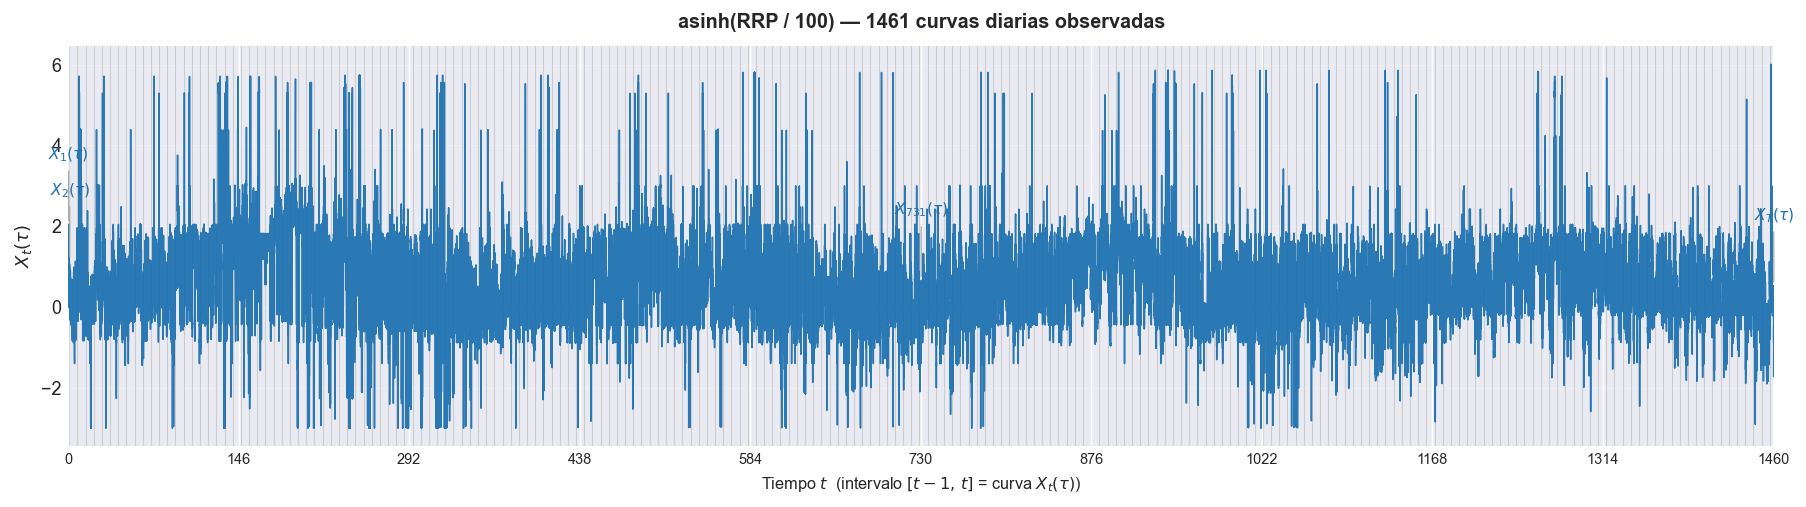

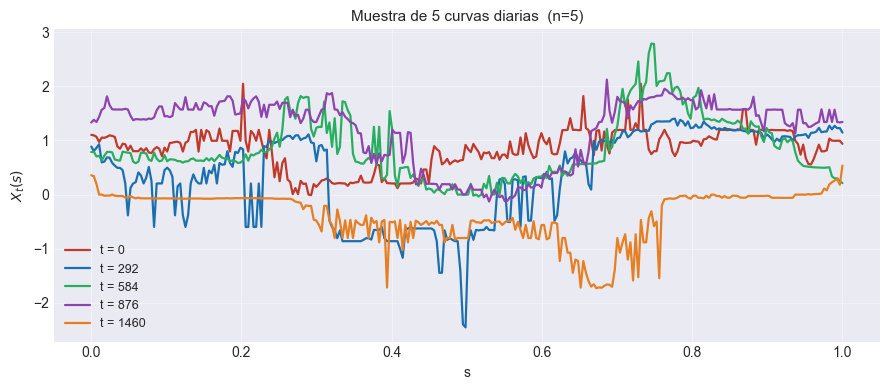

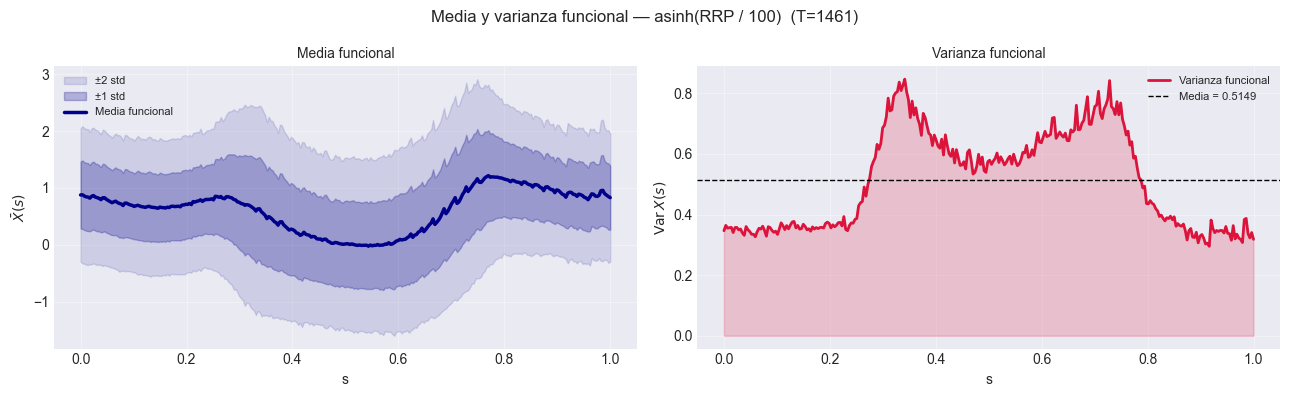

In [7]:
highlight_idx = [0, 1, T // 2, T - 1]

plot_fts_empirical(
    X_raw, grilla, highlight_idx=highlight_idx, separator_every=7,
    title=f"{VARIABLE} — {T} curvas diarias observadas")
replicar_figura("01_fts_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_empirical_sample(
    X_raw, grilla, sample_idx=[0, T // 5, 2 * T // 5, 3 * T // 5, T - 1],
    title="Muestra de 5 curvas diarias")
replicar_figura("02_muestra_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_mean_and_variance(
    X_raw, grilla, show_std1=True, show_std2=True,
    title=f"Media y varianza funcional — {VARIABLE}")
replicar_figura("03_media_varianza_raw.png", PATHS_POR_M)
plt.show()

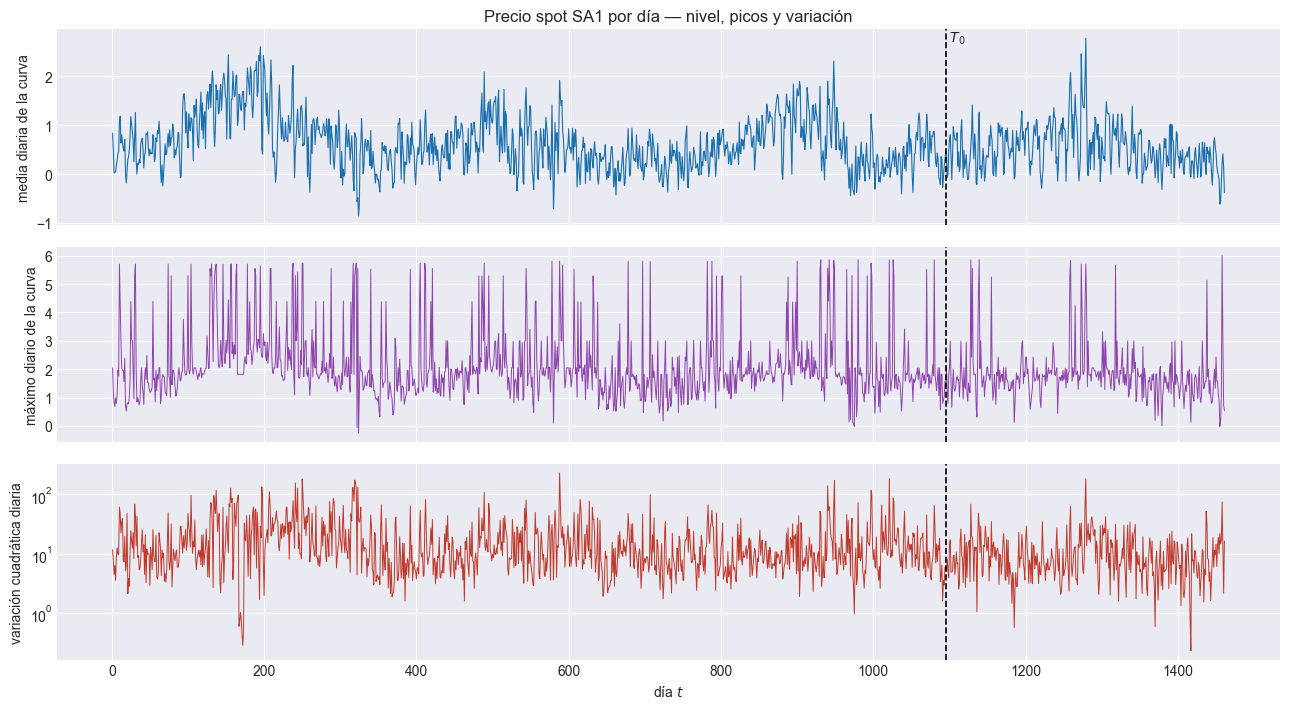

Por tercio de la muestra:  media de la curva · sd · variación cuadrática media
  tercio 1: +0.78034  (sd 0.59793)  ·  var.cuad. 2.324e+01
  tercio 2: +0.59071  (sd 0.51723)  ·  var.cuad. 1.596e+01
  tercio 3: +0.48503  (sd 0.45451)  ·  var.cuad. 1.337e+01
curva train [-2.998, 5.858]  test [-2.901, 6.006]


In [8]:
# Nivel de la curva y variacion cuadratica por dia con el corte train/test: los regimenes
# del precio viven en el nivel medio diario y en la escala de los picos.
_T0_prev = T0

fig, axes = plt.subplots(3, 1, figsize=(13, 7.2), sharex=True)
axes[0].plot(np.arange(1, T + 1), _nivel, lw=0.8, color="#1a6faf")
axes[0].set_ylabel("media diaria de la curva")
axes[1].plot(np.arange(1, T + 1), X_raw.max(axis=1), lw=0.7, color="#8e44ad")
axes[1].set_ylabel("máximo diario de la curva")
axes[2].plot(np.arange(1, T + 1), VOL_DIA, lw=0.7, color="#c0392b")
axes[2].set_yscale("log")
axes[2].set_ylabel("variación cuadrática diaria")
for ax in axes:
    ax.axvline(_T0_prev, color="k", ls="--", lw=1.2)
axes[0].text(_T0_prev, axes[0].get_ylim()[1], r" $T_0$", va="top", fontsize=10)
axes[2].set_xlabel("día $t$")
axes[0].set_title("Precio spot SA1 por día — nivel, picos y variación")
fig.tight_layout()
replicar_figura("04_serie_diaria.png", PATHS_POR_M, fig=fig)
plt.show()

print("Por tercio de la muestra:  media de la curva · sd · variación cuadrática media")
for i, (_n3, _v3) in enumerate(zip(np.array_split(_nivel, 3), np.array_split(VOL_DIA, 3)), 1):
    print(f"  tercio {i}: {_n3.mean():+.5f}  (sd {_n3.std(ddof=1):.5f})  ·  var.cuad. {_v3.mean():.3e}")
print(f"curva train [{X_raw[:_T0_prev].min():.3f}, {X_raw[:_T0_prev].max():.3f}]  "
      f"test [{X_raw[_T0_prev:].min():.3f}, {X_raw[_T0_prev:].max():.3f}]")

### 2.4 Persistencia de curvas

Sólo `X_curves.npy` (la curva de `CURVA`): **no** hay `X_curves_true.npy` porque no hay curva sin ruido. El objetivo de evaluación es la **curva suavizada** (§3.2), que `_04`/`_05` reconstruyen desde la representación B-spline.

In [9]:
_p = guardar_en_todos(guardar_curvas, PATHS_POR_M, X_raw, grilla)      # sin X_true: no existe
for clave, ruta in _p.items():
    print(f"[functional] {clave:12s} -> {ruta.name}   (replicado en {len(PATHS_POR_M)} directorios)")

# Análogo real de simulation_config.json. Documenta la fuente.
for _M, _p in PATHS_POR_M.items():
    dataset_config = {
        "fuente":        [str(r) for r in ARCHIVOS_MENSUALES],
        "mercado":       f"AEMO NEM, region {REGION}, precio spot RRP a 5 min, hora del NEM (UTC+10)",
        "curva":         CURVA,
        "variable":      VARIABLE,
        "serie_id":      SERIE_ID,
        "ventana_id":    int(VENTANA_ID),
        "fecha_inicio_pedida": FECHA_INICIO,
        "fecha_fin_pedida":    FECHA_FIN,
        "fecha_inicio":  str(pd.Timestamp(DIAS[0]).date()),
        "fecha_fin":     str(pd.Timestamp(DIAS[-1]).date()),
        "T": int(T), "G": int(G),
        "prop_train":    float(PROP_TRAIN),
        "barras_dia":    int(BARRAS_DIA),
        "escala_asinh":  float(ESCALA_ASINH),
        "max_hueco_dia": float(MAX_HUECO_DIA),
        "interpolacion": "lineal dentro del dia (sin huecos en estos datos)",
        "dias_descartados": DESCARTES.to_dict(orient="records"),
        "diagnostico":   diagnostico,
        "experiment_id": eid_de(_M),
        "m_fpca":        int(_M),
        "m_fpca_list":   [int(m) for m in M_FPCA_LIST],
        "seed":          SEED,
        "procesado":     datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    }
    with open(_p["raw"] / "dataset_config.json", "w", encoding="utf-8") as f:
        json.dump(dataset_config, f, indent=2, ensure_ascii=False)
    pd.Series(DIAS, name="dia").to_csv(_p["raw"] / "dias.csv", index=False)
    print(f"[raw · M={_M}] dataset_config.json · dias.csv")

[functional] curvas       -> X_curves.npy   (replicado en 10 directorios)
[functional] grilla       -> domain_grid.npy   (replicado en 10 directorios)
[raw · M=1] dataset_config.json · dias.csv
[raw · M=2] dataset_config.json · dias.csv
[raw · M=3] dataset_config.json · dias.csv
[raw · M=4] dataset_config.json · dias.csv
[raw · M=5] dataset_config.json · dias.csv
[raw · M=6] dataset_config.json · dias.csv
[raw · M=7] dataset_config.json · dias.csv
[raw · M=8] dataset_config.json · dias.csv
[raw · M=9] dataset_config.json · dias.csv
[raw · M=10] dataset_config.json · dias.csv


### 2.5 Partición temporal

Todo objeto **estimado a partir de los datos** —GCV de la base, FPCA,
estandarizador (en identidad)— se ajusta sólo con $\{1,\dots,T_0\}$ y se aplica
al bloque de prueba mediante `transform`.

In [10]:
# T0 ya se fijo en §2.2 (corte de la ventana)
assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train, idx_test = np.arange(0, T0), np.arange(T0, T)
X, X_train, X_test = X_raw, X_raw[idx_train], X_raw[idx_test]

print(f"entrenamiento : t ∈ [1, {T0}]      → {X_train.shape}   "
      f"(hasta {pd.Timestamp(DIAS[T0 - 1]).date()})")
print(f"prueba        : t ∈ [{T0+1}, {T}]  → {X_test.shape}")
print(f"proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

entrenamiento : t ∈ [1, 1096]      → (1096, 288)   (hasta 2024-12-31)
prueba        : t ∈ [1097, 1461]  → (365, 288)
proporción    : 75.0% / 25.0%


## 3. Representación funcional B-spline

### 3.1 Barrido GCV sobre `(n_basis, order)`

El GCV **sugiere**; la elección es del analista y se declara en 3.2.

,n_basis,order,var_retained,rmse_mean,rmse_max,gcv_mean
0,2,2,40.0306%,0.536642,1.493112,0.334791
1,3,2,63.5005%,0.411089,1.302122,0.205198
2,4,2,62.2328%,0.420529,1.355643,0.213823
3,5,2,75.9648%,0.327877,1.083993,0.137041
4,6,2,79.0188%,0.306155,1.101836,0.120478
5,7,2,81.5228%,0.289596,0.888369,0.106856
6,8,2,83.5772%,0.269936,0.915053,0.095655
7,9,2,85.1593%,0.254100,0.898527,0.087060
8,10,2,86.2334%,0.245562,0.867860,0.081342
9,11,2,86.8835%,0.239013,0.877527,0.078061



GCV mínimo → n_basis=29, order=3  (var retenida 92.0896%)
! el mínimo está en el borde del rango (n_basis=29): el GCV pediría más funciones. No se amplía el rango; §3.6 muestra el piso de la base.


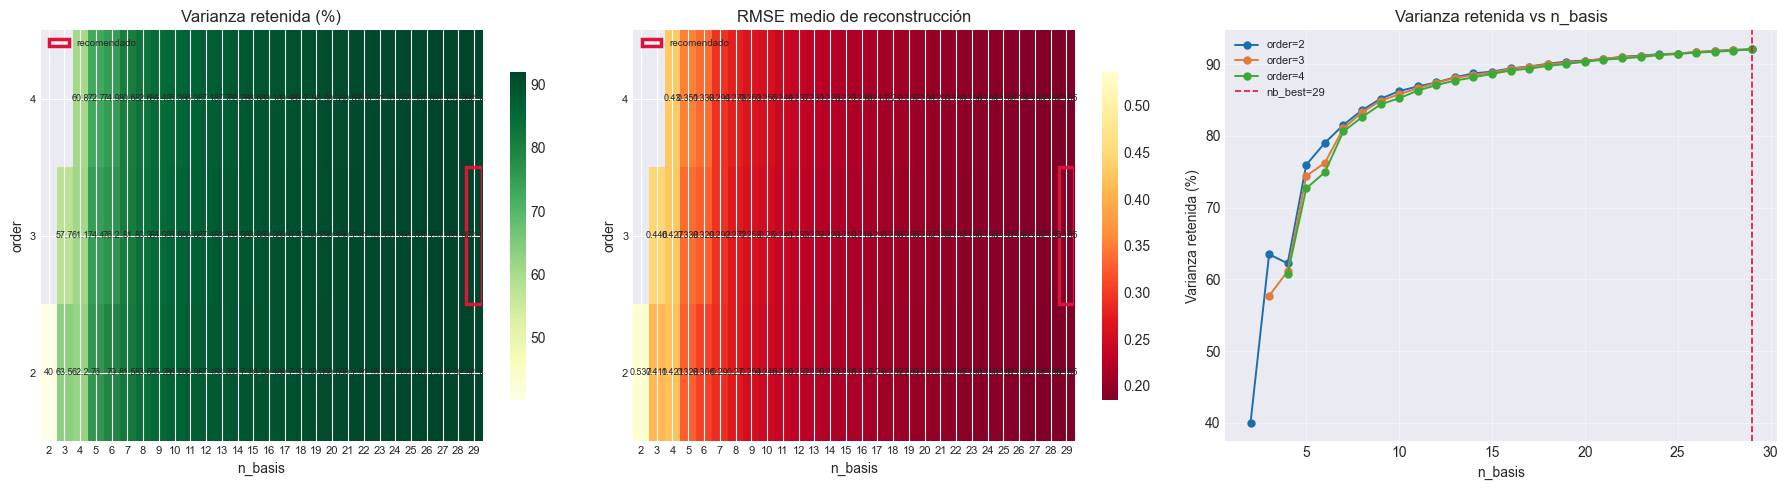

In [11]:
N_BASIS_RANGE = range(2, min(30, T0 // 2))   # acotado por T0
ORDER_RANGE   = range(2, 5)

registros = []
for orden in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < orden:
            continue
        try:
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=orden)
            TH_tmp = fr_tmp.fit_transform(X_train, grilla)     # sólo train
            X_rec  = fr_tmp.reconstruct(TH_tmp)

            L_i    = X_train.shape[1]
            sse_c  = np.sum((X_train - X_rec) ** 2, axis=1)
            ss_tot = np.sum((X_train - X_train.mean(axis=0, keepdims=True)) ** 2)
            gcv_c  = (L_i * sse_c / (L_i - nb) ** 2 if L_i > nb
                      else np.full_like(sse_c, np.nan))
            registros.append({
                "n_basis": nb, "order": orden,
                "var_retained": 1.0 - sse_c.sum() / ss_tot,
                "rmse_mean": np.sqrt(sse_c / L_i).mean(),
                "rmse_max":  np.sqrt(sse_c / L_i).max(),
                "gcv_mean":  float(np.mean(gcv_c)),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={orden}: {e}")

sel_df   = pd.DataFrame(registros)
best_row = sel_df.dropna(subset=["gcv_mean"]).nsmallest(1, "gcv_mean").iloc[0]
nb_best, ord_best = int(best_row["n_basis"]), int(best_row["order"])

display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}",
             "rmse_max": "{:.6f}", "gcv_mean": "{:.6f}"})
    .background_gradient(subset=["gcv_mean"], cmap="YlOrRd_r")
    .background_gradient(subset=["var_retained"], cmap="YlGn"))

print(f"\nGCV mínimo → n_basis={nb_best}, order={ord_best}  "
      f"(var retenida {best_row['var_retained']:.4%})")
if nb_best == max(N_BASIS_RANGE):
    print(f"! el mínimo está en el borde del rango (n_basis={nb_best}): el GCV pediría "
          "más funciones. No se amplía el rango; §3.6 muestra el piso de la base.")

plot_seleccion_basis(sel_df, nb_best, ord_best)
replicar_figura("05_seleccion_basis.png", PATHS_POR_M)
plt.show()

### 3.2 `[CONFIG]` Base elegida y ajuste

`center=False` es imprescindible: con `center=True` la reconstrucción es un
mapa **afín**, y la función media contaminaría la base recuperada por
`base_en_grilla`, la matriz de Gram y las autofunciones.

`X_SUAV = fr.reconstruct(THETA)` es el **objetivo de evaluación** (docs §03_05_00).

Base elegida : n_basis=29, order=3
Sugerido GCV : n_basis=29, order=3   (coinciden)
THETA (1461, 29)  (train=1096, test=365)
MISE(suavizada, observada) = 0.039159


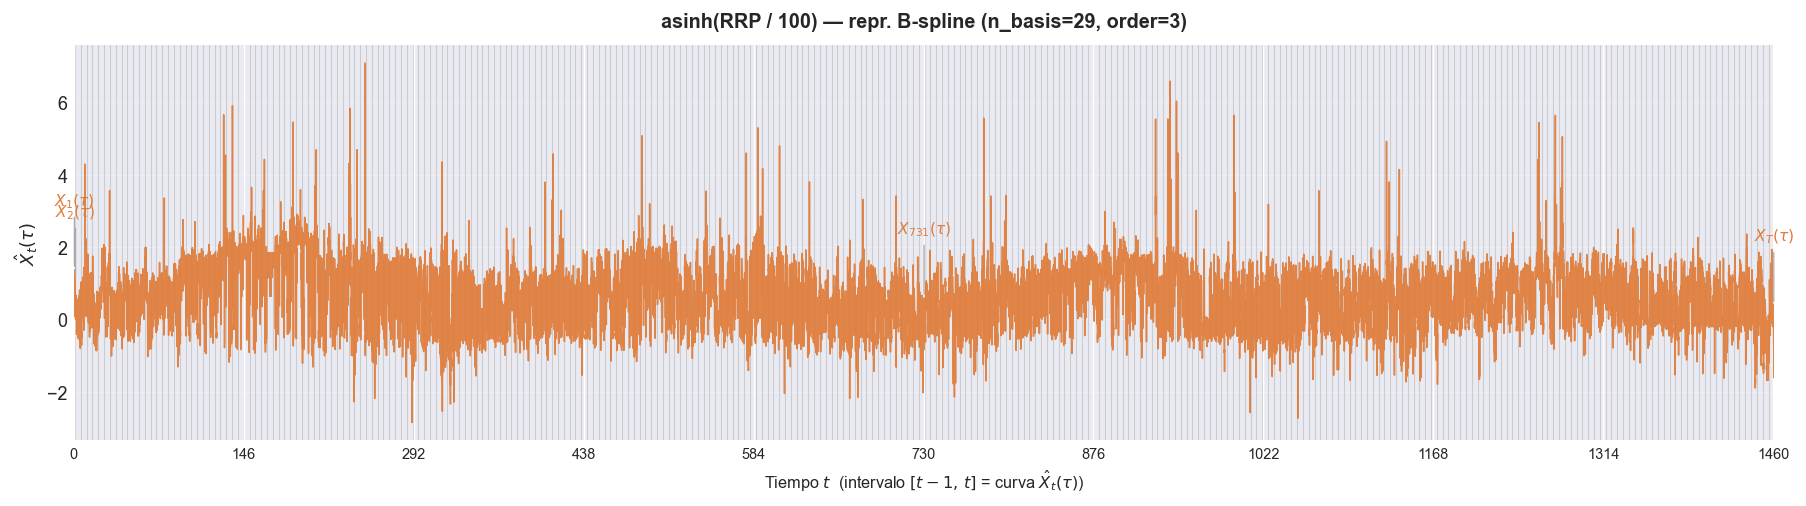

[functional] functional_representation.pkl + theta.csv + fr_config.json   (replicado en 10 directorios)


In [12]:
NB_ELEGIDO  = nb_best     # ← decisión del analista
ORD_ELEGIDO = ord_best

print(f"Base elegida : n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}")
print(f"Sugerido GCV : n_basis={nb_best}, order={ord_best}"
      + ("   (coinciden)" if (NB_ELEGIDO, ORD_ELEGIDO) == (nb_best, ord_best)
         else "   ← DIFIERE de la sugerencia; justificar en la tesis"))

fr = FunctionalRepresentation(method="bspline", n_basis=NB_ELEGIDO,
                              order=ORD_ELEGIDO, center=False)
fr.fit(X_train, grilla)                       # sólo train
THETA       = fr.transform(X, grilla)         # (T, K) serie completa
THETA_train = THETA[idx_train]
X_SUAV      = fr.reconstruct(THETA)           # objetivo de evaluacion (docs 03_05_00)
print(f"THETA {THETA.shape}  (train={T0}, test={T - T0})")
print(f"MISE(suavizada, observada) = {mise(X, X_SUAV, grilla):.6f}")

plot_fts_functional(
    X, grilla, fr=fr, highlight_idx=highlight_idx, separator_every=5,
    title=f"{VARIABLE} — repr. B-spline (n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO})")
replicar_figura("06_fts_funcional_bspline.png", PATHS_POR_M)
plt.show()

guardar_en_todos(guardar_representacion, PATHS_POR_M, fr, THETA,
    extra={"T0": int(T0), "prop_train": float(PROP_TRAIN), "ajustado_en": "train",
           "center": bool(fr.center), "n_basis": int(NB_ELEGIDO),
           "order": int(ORD_ELEGIDO), "n_basis_gcv": nb_best, "order_gcv": ord_best})
print(f"[functional] functional_representation.pkl + theta.csv + fr_config.json"
      f"   (replicado en {len(PATHS_POR_M)} directorios)")

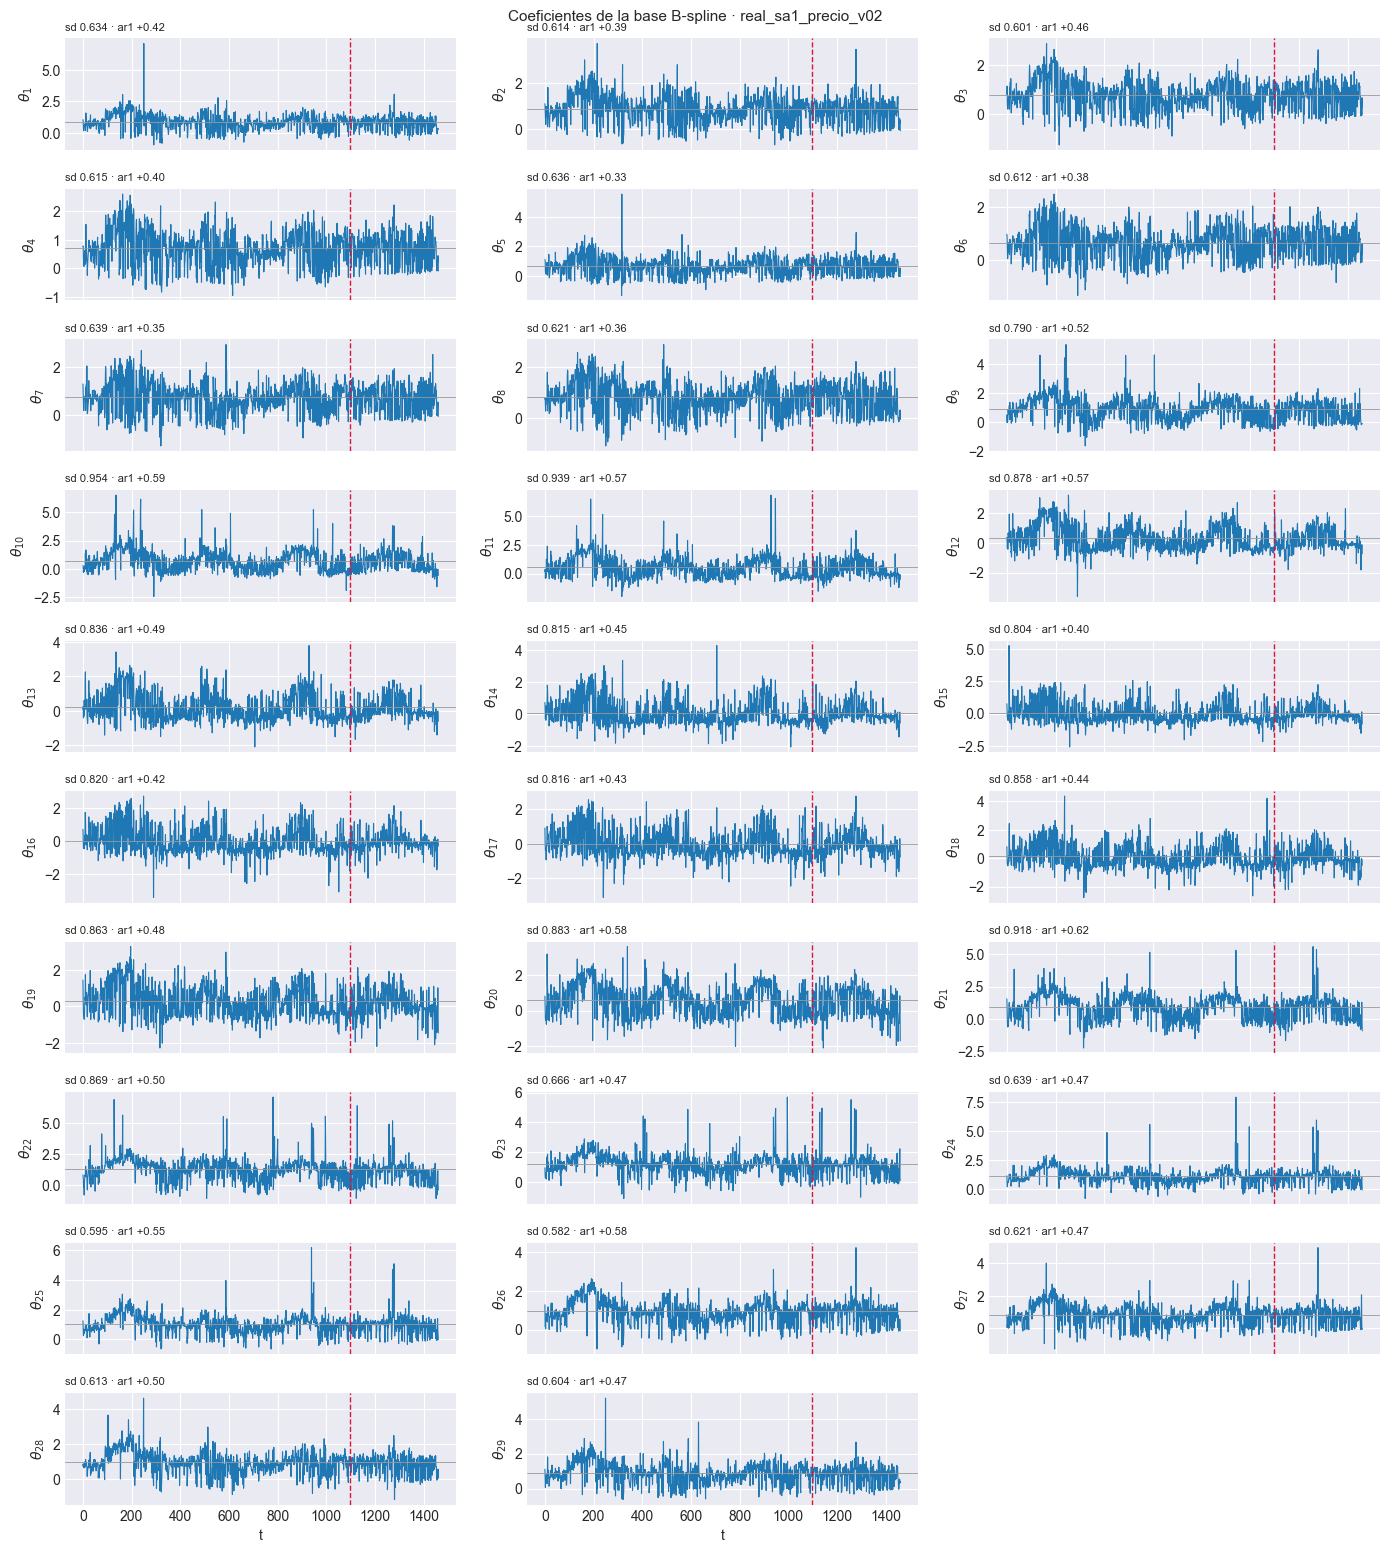

In [13]:
# Un panel por coeficiente theta_j de la base B-spline elegida (T, K).
fig = plot_series_componentes(
    THETA, T0=T0, simbolo=r"\theta", ncols=3,
    titulo=f"Coeficientes de la base B-spline · {EXPERIMENT_BASE}")
replicar_figura("06_series_coeficientes.png", PATHS_POR_M, fig=fig)
plt.show()

### 3.3 FPCA generalizado en $L^2$ y diagnóstico

In [14]:
Phi  = base_en_grilla(fr, THETA.shape[1])        # (G, K)
fpca = FPCA_L2().fit(THETA_train, Phi, grilla)

# tol 1e-8 y no 1e-10: con K=29 y la curva en esta escala, var(xi)/lambda de las componentes
# de autovalor mínimo sale a ~1e-10 de error relativo, sólo redondeo.
TOL_FPCA = 1e-8
_ver = fpca.verificar(THETA_train, fr=fr, tol=TOL_FPCA)
print("Verificación FPCA_L2 (entrenamiento):")
for k, v in _ver.items():
    print(f"  {k:34s} = {v:.3e}" if isinstance(v, float) else f"  {k:34s} = {v}")

cond = _ver["cond_W"]
nota = ("← MUY ALTO: reduzca n_basis" if cond > 1e10 else
        "← alto: vigile las componentes menores" if cond > 1e6 else "(sano)")
print(f"\ncond(W) = {cond:.3e}  {nota}")

assert _ver["todo_ok"], ("Las identidades del FPCA generalizado no se cumplen. "
                         "Si falla err_linealidad_reconstruct_rel, revise center=False.")

Verificación FPCA_L2 (entrenamiento):
  M                                  = 29
  K                                  = 29
  n_ajuste                           = 1096
  cond_W                             = 1.029e+01
  err_ortonormalidad_L2              = 2.442e-15
  err_ortonormalidad_gram            = 2.220e-15
  var_explicada                      = 1.000e+00
  err_rutas_reconstruccion           = 8.882e-16
  err_linealidad_reconstruct         = 0.000e+00
  err_linealidad_reconstruct_rel     = 0.000e+00
  err_media_scores                   = 3.287e-16
  err_media_scores_rel               = 6.282e-15
  err_var_scores_vs_lambda           = 5.551e-17
  err_var_scores_vs_lambda_rel       = 9.070e-14
  err_correlacion_lag0               = 6.686e-14
  criterios_evaluados                = ['err_ortonormalidad_L2', 'err_ortonormalidad_gram', 'err_rutas_reconstruccion', 'err_correlacion_lag0', 'err_linealidad_reconstruct_rel', 'err_media_scores_rel', 'err_var_scores_vs_lambda_rel']
  todo_ok   

,componente,autovalor,var_ratio,var_acum,ar1_propio
0,1,3.2746e-01,64.3697%,64.3697%,+0.724
1,2,4.9916e-02,9.8122%,74.1819%,+0.198
2,3,3.8500e-02,7.5680%,81.7499%,+0.230
3,4,2.5543e-02,5.0210%,86.7709%,+0.371
4,5,1.5452e-02,3.0375%,89.8083%,+0.192
5,6,8.1244e-03,1.5970%,91.4054%,+0.145
6,7,7.4559e-03,1.4656%,92.8710%,+0.175
7,8,5.1626e-03,1.0148%,93.8858%,+0.022
8,9,4.2014e-03,0.8259%,94.7117%,+0.140
9,10,3.6511e-03,0.7177%,95.4294%,+0.095



K disponibles: 29   ·   sugerencia (var ≥ 95%): M = 10
  M=1: var. acum = 64.3697%  ·  sensibilidad
  M=2: var. acum = 74.1819%  ·  sensibilidad
  M=3: var. acum = 81.7499%  ·  sensibilidad
  M=4: var. acum = 86.7709%  ·  sensibilidad
  M=5: var. acum = 89.8083%  ·  sensibilidad
  M=6: var. acum = 91.4054%  ·  sensibilidad
  M=7: var. acum = 92.8710%  ·  sensibilidad
  M=8: var. acum = 93.8858%  ·  sensibilidad
  M=9: var. acum = 94.7117%  ·  sensibilidad
  M=10: var. acum = 95.4294%  ·  regla del 95 %


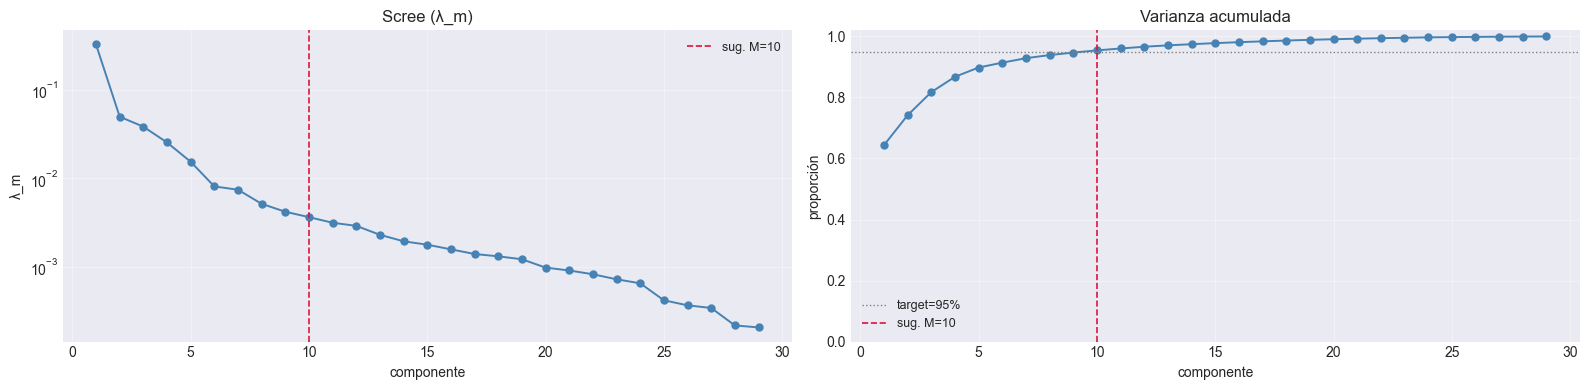

In [15]:
# Varianza != dinamica: una FPC de varianza baja puede tener AR fuerte.
K   = fpca.evals.size
S_a = (THETA_train - fpca.mu_theta) @ (fpca.W @ fpca.B_full)     # (T0, K)
ar1 = (S_a[1:] * S_a[:-1]).sum(0) / np.clip((S_a[:-1] ** 2).sum(0), 1e-12, None)

VAR_TARGET  = 0.95
M_SUGERIDO  = fpca.seleccionar_M(VAR_TARGET)

display(pd.DataFrame({
    "componente": np.arange(1, K + 1), "autovalor": fpca.evals,
    "var_ratio": fpca.var_ratio, "var_acum": fpca.var_cum, "ar1_propio": ar1,
}).head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}",
     "var_acum": "{:.4%}", "ar1_propio": "{:+.3f}"})
    .background_gradient(subset=["var_ratio"], cmap="YlGn")
    .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1))

print(f"\nK disponibles: {K}   ·   sugerencia (var ≥ {VAR_TARGET:.0%}): M = {M_SUGERIDO}")

# K lo fija el GCV y ACOTA el barrido
assert max(M_FPCA_LIST) <= K, (
    f"M_FPCA_LIST={list(M_FPCA_LIST)} excede el K disponible: la base elegida "
    f"(n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}) da K = {K} componentes. "
    f"Reduzca el barrido o elija una base con más funciones en §3.2.")

_frontera = max(3, int(np.ceil(0.75 * K)))
for _M in M_FPCA_LIST:
    _marca = "regla del 95 %" if _M == M_SUGERIDO else "sensibilidad"
    _aviso = ("   <- cerca del techo K: componente en buena medida artefacto "
              "de una base corta" if _M >= _frontera else "")
    print(f"  M={_M}: var. acum = {fpca.var_cum[_M-1]:.4%}  ·  {_marca}{_aviso}")

plot_fpca_scree(fpca.evals, fpca.var_cum, M_SUGERIDO, var_target=VAR_TARGET)
replicar_figura("07_fpca_scree.png", PATHS_POR_M)
plt.show()

### 3.4 Series de los componentes de la FPCA

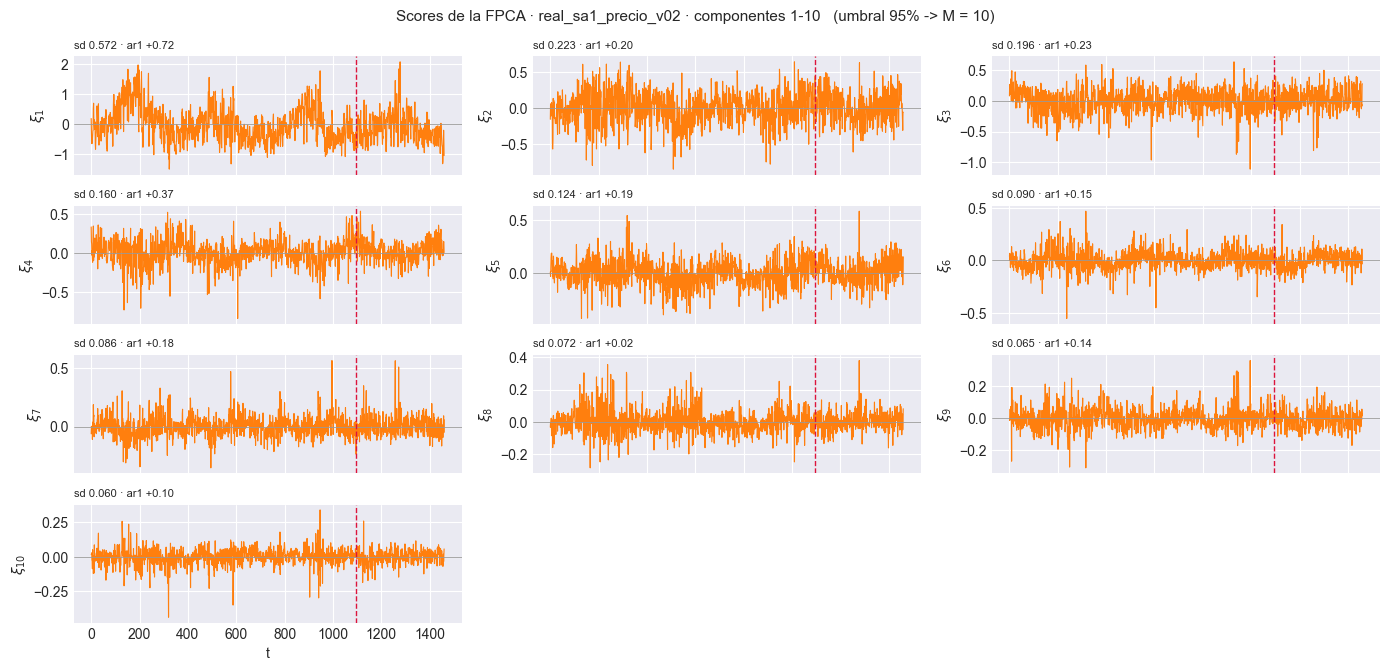

componentes graficadas : 1-10  de K = 29
var. acumulada hasta 10 : 95.4294%


In [16]:
# [CONFIG] hasta que componente se grafica: todas las del barrido.
N_SERIES_SCORES = max(M_FPCA_LIST)

assert 1 <= N_SERIES_SCORES <= K, f"N_SERIES_SCORES={N_SERIES_SCORES} fuera de [1, {K}]."

# B_full y no B: no depende de set_M. Serie completa, no solo train.
XI = (THETA - fpca.mu_theta) @ (fpca.W @ fpca.B_full)      # (T, K)

fig = plot_series_componentes(
    XI[:, :N_SERIES_SCORES], T0=T0, simbolo=r"\xi", color="C1", ncols=3,
    titulo=f"Scores de la FPCA · {EXPERIMENT_BASE} · componentes 1-{N_SERIES_SCORES}   "
           f"(umbral {VAR_TARGET:.0%} -> M = {M_SUGERIDO})")
replicar_figura("07b_series_scores.png", PATHS_POR_M, fig=fig)
plt.show()

print(f"componentes graficadas : 1-{N_SERIES_SCORES}  de K = {K}")
print(f"var. acumulada hasta {N_SERIES_SCORES} : {fpca.var_cum[N_SERIES_SCORES-1]:.4%}")

### 3.5 Componentes estandarizados — sólo contraste

Los scores **no** se estandarizan: a MATLAB van los de §3.4, en su escala propia. Esta sección muestra lo que se descartó.

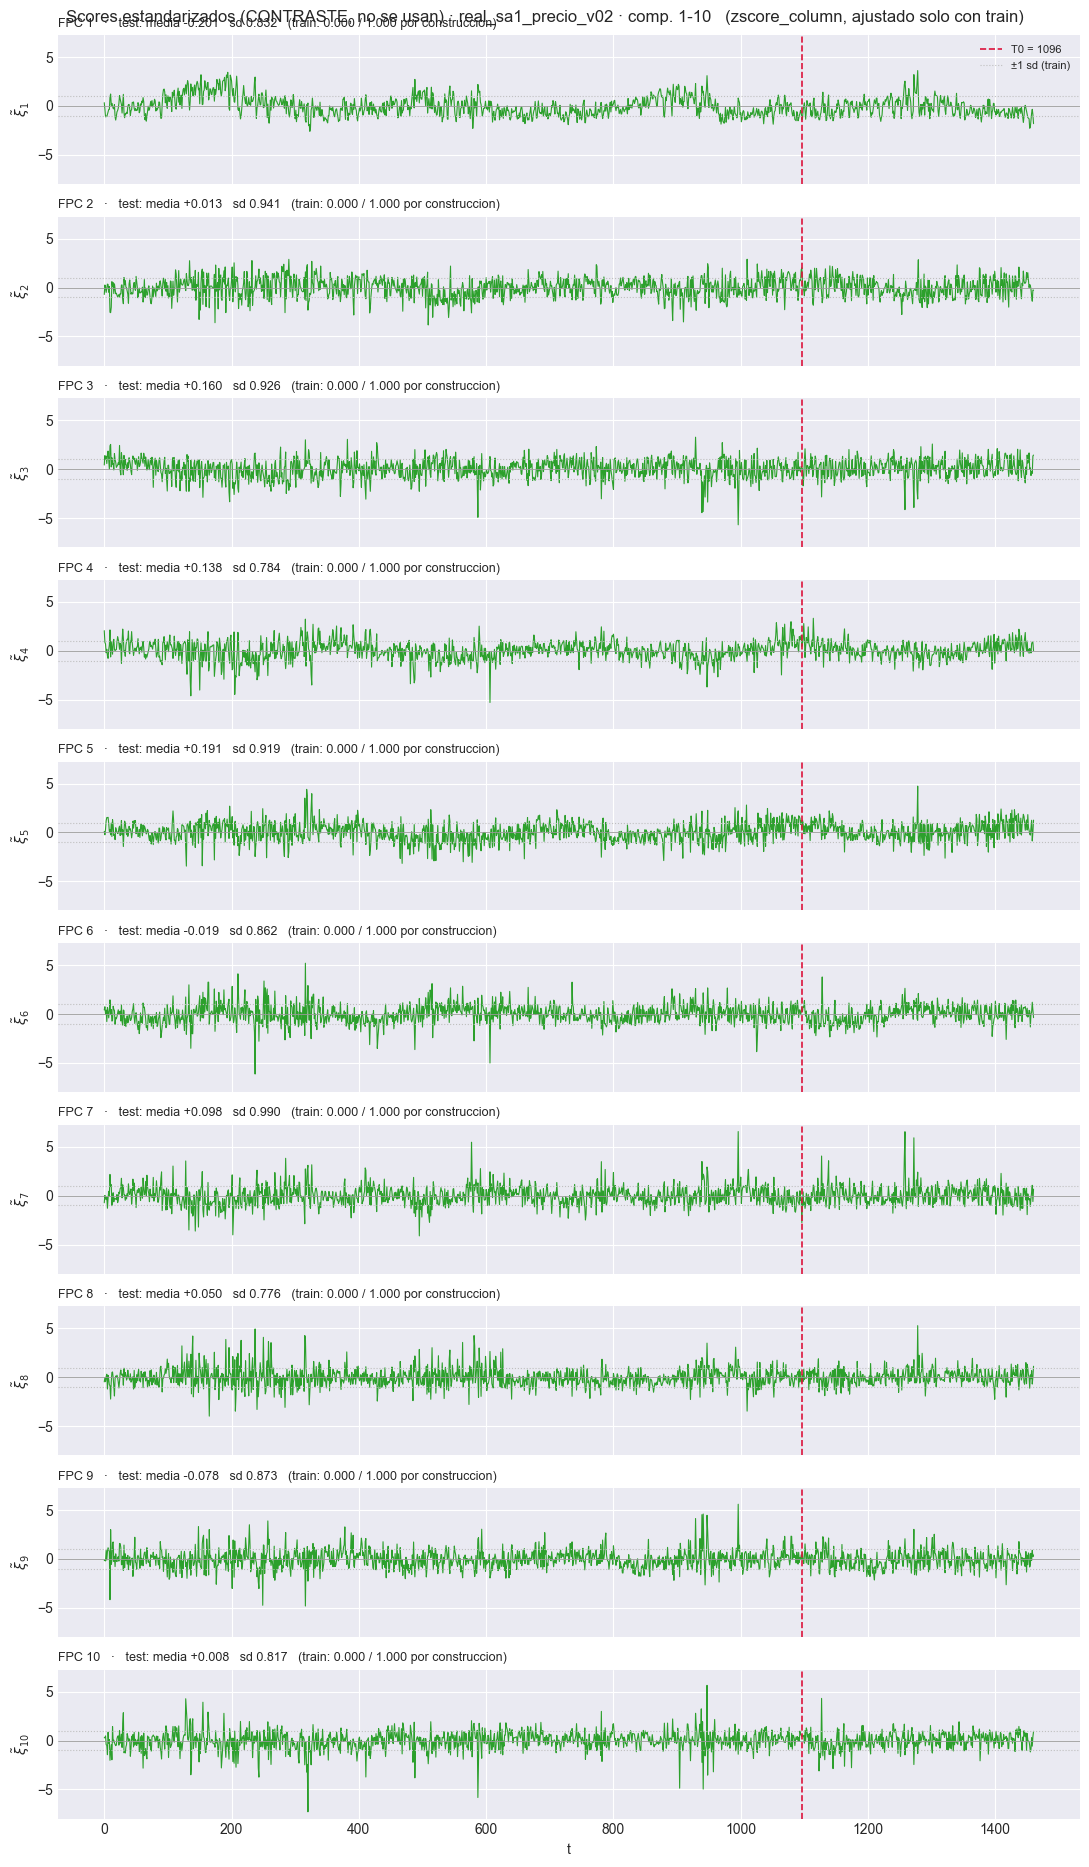

escala original  sd(train) : [0.572  0.2233 0.1961 0.1597 0.1243 0.0901 0.0863 0.0718 0.0648 0.0604]
estandarizado    sd(test)  : [0.8318 0.9407 0.9265 0.7842 0.9185 0.8623 0.9904 0.7757 0.8725 0.817 ]    <- lejos de 1 = el bloque de prueba no comparte escala con train


In [17]:
_std = DataStandardizer(method="zscore_column", ddof=0)
_std.fit(XI[idx_train, :N_SERIES_SCORES], etiqueta=f"train[1:{T0}]")
XI_STD = _std.transform(XI[:, :N_SERIES_SCORES])            # (T, N_SERIES_SCORES)

fig, axes = plt.subplots(N_SERIES_SCORES, 1, sharex=True, sharey=True,
                         figsize=(11, 1.9 * N_SERIES_SCORES))
axes = np.atleast_1d(axes)
for k, ax in enumerate(axes):
    ax.plot(np.arange(T), XI_STD[:, k], lw=0.8, color="C2")
    ax.axvline(T0, color="crimson", ls="--", lw=1.2)
    ax.axhline(0, color="0.6", lw=0.6)
    for _s in (-1, 1):
        ax.axhline(_s, color="0.75", ls=":", lw=0.8)
    ax.set_ylabel(rf"$\tilde\xi_{{{k+1}}}$")
    ax.set_title(f"FPC {k+1}   ·   test: media {XI_STD[idx_test, k].mean():+.3f}   "
                 f"sd {XI_STD[idx_test, k].std():.3f}   "
                 f"(train: 0.000 / 1.000 por construccion)",
                 fontsize=9, loc="left")
axes[-1].set_xlabel("t")
axes[0].plot([], [], color="crimson", ls="--", lw=1.2, label=f"T0 = {T0}")
axes[0].plot([], [], color="0.75", ls=":", lw=0.8, label="±1 sd (train)")
axes[0].legend(loc="upper right", fontsize=8)

fig.suptitle(f"Scores estandarizados (CONTRASTE, no se usan) · {EXPERIMENT_BASE} · comp. 1-"
             f"{N_SERIES_SCORES}   (zscore_column, ajustado solo con train)")
fig.tight_layout()
plt.show()

print(f"escala original  sd(train) : "
      f"{np.array2string(XI[idx_train, :N_SERIES_SCORES].std(0), precision=4)}")
print(f"estandarizado    sd(test)  : "
      f"{np.array2string(XI_STD[idx_test].std(0), precision=4)}"
      "    <- lejos de 1 = el bloque de prueba no comparte escala con train")

### 3.6 Comparación de las tres curvas: cruda, B-spline y FPCA$_M$

**Diagnóstico del preprocesamiento, no métrica reportable** (las diez de §02_02_03 se calculan en `_04`/`_05`).

| par | qué mide |
|---|---|
| MISE(cruda, B-spline) | piso de la base: **invariante en $M$** |
| MISE(cruda, FPCA$_M$) | error total de representación |
| MISE(B-spline, FPCA$_M$) | truncamiento FPCA: baja con $M$ |

La figura toma los días mejor, mediano y peor representados por FPCA$_M$ (con $M$=`M_REF_DIAS`) más el de mayor y menor volatilidad realizada, y superpone las tres curvas, un panel por $M$.

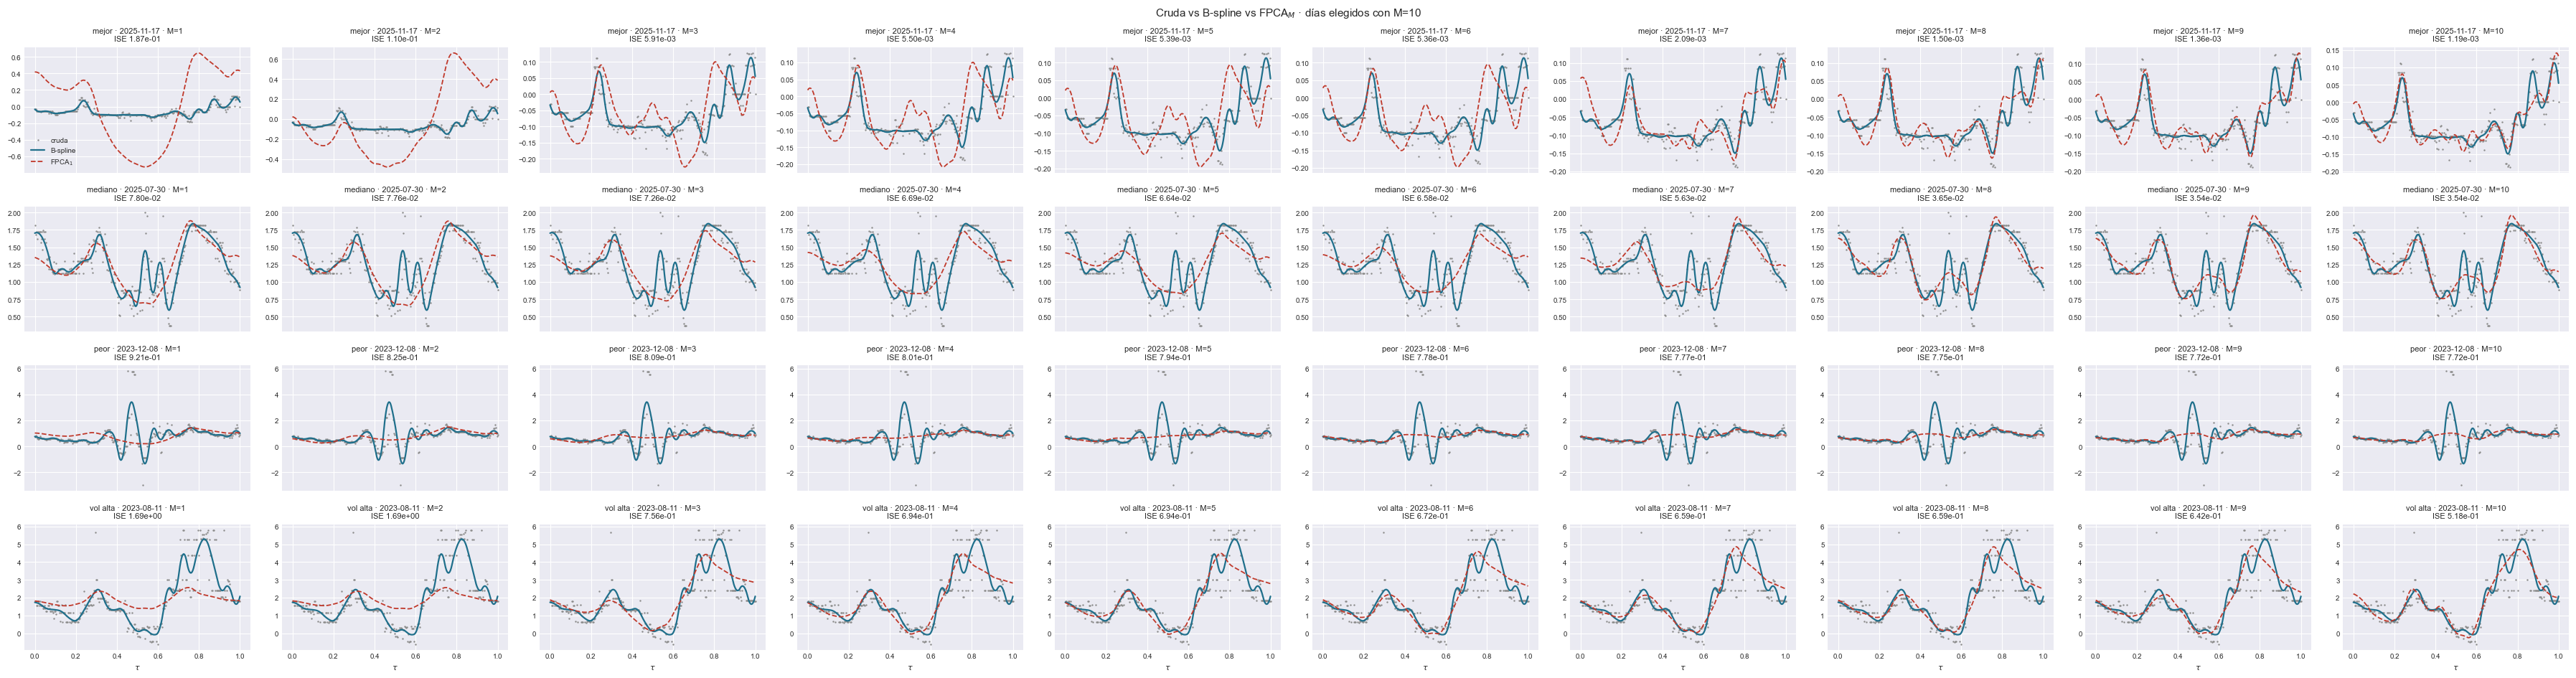

In [18]:
_w_tau = pesos_trapezoidales(grilla)
M_REF_DIAS = M_SUGERIDO if M_SUGERIDO in M_FPCA_LIST else min(M_FPCA_LIST)

X_FPCA = {}
filas_3c = []
for _M in M_FPCA_LIST:
    fpca.set_M(int(_M))
    X_FPCA[_M] = fpca.reconstruct(fpca.transform(THETA))      # (T, G)
    for bloque, _i in (("train", idx_train), ("test", idx_test)):
        _pc = mise(X[_i], X_SUAV[_i], grilla)
        _pf = mise(X[_i], X_FPCA[_M][_i], grilla)
        filas_3c.append({
            "M": int(_M), "bloque": bloque,
            "var_explicada": float(fpca.var_cum[_M - 1]),
            "mise_cruda_bspline": _pc,
            "mise_cruda_fpca": _pf,
            "mise_bspline_fpca": mise(X_SUAV[_i], X_FPCA[_M][_i], grilla),
            "frac_piso_base": _pc / _pf if _pf > 0 else np.nan,
        })

TRES_CURVAS = pd.DataFrame(filas_3c).set_index(["M", "bloque"])
for _p in PATHS_POR_M.values():
    TRES_CURVAS.to_csv(_p["out_report"] / "10_tres_curvas_mise.csv")
display(TRES_CURVAS.style
        .format({"var_explicada": "{:.4%}", "mise_cruda_bspline": "{:.3e}",
                 "mise_cruda_fpca": "{:.3e}", "mise_bspline_fpca": "{:.3e}",
                 "frac_piso_base": "{:.1%}"})
        .set_caption("Tres curvas · frac_piso_base = MISE(cruda, B-spline) / "
                     "MISE(cruda, FPCA_M) · diagnóstico, no métrica reportable"))

# Días de la figura: ISE por curva con la cuadratura común.
_ise = ((X - X_FPCA[M_REF_DIAS]) ** 2) @ _w_tau
_orden = np.argsort(_ise)
_cand = {"mejor": int(_orden[0]), "mediano": int(_orden[len(_orden) // 2]),
         "peor": int(_orden[-1]), "vol alta": int(np.argmax(VOL_DIA)),
         "vol baja": int(np.argmin(VOL_DIA))}
DIAS_3C = {}
for _nom, _i in _cand.items():
    if _i not in DIAS_3C.values():
        DIAS_3C[_nom] = _i

fig, axes = plt.subplots(len(DIAS_3C), len(M_FPCA_LIST),
                         figsize=(3.6 * len(M_FPCA_LIST), 2.4 * len(DIAS_3C)),
                         squeeze=False, sharex=True)
for r, (_nom, _i) in enumerate(DIAS_3C.items()):
    for c, _M in enumerate(M_FPCA_LIST):
        ax = axes[r, c]
        ax.plot(grilla, X[_i], ".", color="0.55", ms=1.5, label="cruda")
        ax.plot(grilla, X_SUAV[_i], color="#1f6f8b", lw=1.6, label="B-spline")
        ax.plot(grilla, X_FPCA[_M][_i], color="#c0392b", lw=1.3, ls="--",
                label=f"FPCA$_{{{_M}}}$")
        ax.set_title(f"{_nom} · {pd.Timestamp(DIAS[_i]).date()} · M={_M}\n"
                     f"ISE {(((X[_i] - X_FPCA[_M][_i]) ** 2) @ _w_tau):.2e}",
                     fontsize=8)
        ax.tick_params(labelsize=7)
axes[0, 0].legend(fontsize=7)
for ax in axes[-1]:
    ax.set_xlabel(r"$\tau$", fontsize=8)
fig.suptitle(f"Cruda vs B-spline vs FPCA$_M$ · días elegidos con M={M_REF_DIAS}",
             fontsize=11)
fig.tight_layout()
replicar_figura("10_tres_curvas.png", PATHS_POR_M, fig=fig)
plt.show()

## 4. El bucle sobre `M_FPCA_LIST`

- §4.1: `set_M(M)` y scores; contraste con la regla del 95 %
- §4.2: estandarizador en **identidad** (los scores van crudos) y artefactos FPCA
- §4.3: diagnóstico de rezagos sobre el bloque de entrenamiento
- §4.4: datasets AR con covariables **cruzadas** (un rezago)
- §4.5: hiperparámetros (Chung §4.2 en escala cruda) y `mcmc_config` — el contrato con MATLAB
- §4.6: `eval_config`, líneas base y `verificar_contrato`


In [19]:
def procesar_punto(M: int) -> dict:
    """Produce TODOS los artefactos del punto M del barrido y verifica su contrato.

    Recibe por clausura los objetos comunes de §2-§3.3 —`fpca` ya ajustado,
    `THETA`, `idx_train`/`idx_test`, `grilla`, `X_SUAV`— y no los recalcula:
    ésa es la garantía de que los puntos comparten datos y base.
    """
    PATHS = PATHS_POR_M[M]
    eid = eid_de(M)
    print(f"\n{'='*70}\nM = {M}   ·   {eid}\n{'='*70}")

    # -- §4.1 Componentes retenidas ------------------------------------------
    assert 1 <= M <= fpca.evals.size, f"M fuera de [1, {fpca.evals.size}]."
    coincide_regla = (M == M_SUGERIDO)
    print(f"M(95 %) según la regla : {M_SUGERIDO}   (K disponible = {fpca.evals.size})")
    print(f"M de este punto        : {M}"
          + ("   (coincide con la regla)" if coincide_regla
             else "   <- DIFIERE de la regla: es un punto de sensibilidad"))

    fpca.set_M(int(M))
    M_fpca = fpca.M

    SCORES       = fpca.transform(THETA)       # (T, M) — base ajustada en train
    SCORES_train = SCORES[idx_train]
    SCORES_test  = SCORES[idx_test]

    print(f"M = {M_fpca}   var. explicada = {fpca.var_cum[M_fpca-1]:.4%}")
    print(f"[train] max|media xi| = {np.abs(SCORES_train.mean(0)).max():.2e}   (~ 0)")
    print(f"[test]  max|media xi| = {np.abs(SCORES_test.mean(0)).max():.3f}")
    print(f"[test]  var xi / lambda = "
          f"{np.array2string(SCORES_test.var(0, ddof=1) / fpca.lambdas, precision=3)}")

    # -- §4.2 Escala de los scores: SIN estandarizar --------------------------
    # Se ajusta con train (verificar_contrato exige n_ajuste == T0) y se deja en
    # identidad: MATLAB recibe los scores en su escala propia.
    scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
    scores_standardizer.fit(SCORES_train, etiqueta=f"train[1:{T0}]")

    _chk = scores_standardizer.verificar_ajuste(T0)
    print(f"[holdout] ajustado con {_chk['n_ajuste']} filas = T0 "
          f"({_chk['etiqueta_ajuste']}) -> ok={_chk['ajuste_ok']}")

    MU_OBS = scores_standardizer.mean.copy()
    SD_OBS = scores_standardizer.std.copy()
    scores_standardizer.mean = np.zeros_like(MU_OBS)
    scores_standardizer.std  = np.ones_like(SD_OBS)

    SCORES_STD       = scores_standardizer.transform(SCORES)
    assert np.allclose(SCORES_STD, SCORES), "la transformacion deberia ser la identidad."
    SCORES_STD_train = SCORES_STD[idx_train]
    SCORES_STD_test  = SCORES_STD[idx_test]

    print(f"\nSCORES_STD {SCORES_STD.shape}   (= SCORES: transformacion identidad)")
    print(f"  [train] media = {np.array2string(MU_OBS, precision=3)}   <- NO se resta")
    print(f"  [train] std   = {np.array2string(SD_OBS, precision=3)}   <- NO se divide")
    print(f"  [test]  media = {np.array2string(SCORES_STD_test.mean(0), precision=3)}")
    print(f"  [test]  std   = {np.array2string(SCORES_STD_test.std(0),  precision=3)}")
    print(f"  rango que vera MATLAB: [{SCORES_STD.min():.3f}, {SCORES_STD.max():.3f}]")

    guardar_estandarizador(PATHS, scores_standardizer)
    _res = guardar_fpca(PATHS, fpca, SCORES, SCORES_STD=SCORES_STD,
                        meta_extra={"T0": int(T0)})
    print(f"\n[functional] artefactos FPCA · cond_W = {_res['meta']['cond_W']:.3e}")

    plot_diagnostico_estandarizacion(
        SCORES_train, SCORES_STD_train, np.arange(1, M_fpca + 1),
        labels=("Scores xi (escala lambda)", "Scores xi entregados (identicos: no se estandariza)"),
        title=f"estadísticas por componente FPCA (M={M})",
        save_path=str(PATHS["out_report"] / "08_diagnostico_estandarizacion.png"))
    plt.show()

    # -- §4.3 Diagnóstico de rezagos (sólo train) ----------------------------
    # Incluye los cruzados: muestra lo que el diseño de rezago propio descarta.
    N_LAGS_MAX = N_LAGS
    T_theta, K_total = SCORES_STD_train.shape

    def _spearman(Y, Xm):
        """Spearman columna a columna vía rangos (pandas, sin scipy)."""
        Yc = pd.DataFrame(Y).rank().to_numpy(); Yc = Yc - Yc.mean(0)
        Xc = pd.DataFrame(Xm).rank().to_numpy(); Xc = Xc - Xc.mean(0)
        return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

    corr_p = np.zeros((K_total, K_total * N_LAGS_MAX))
    corr_s = np.zeros_like(corr_p)
    col_labels = []
    y_block = SCORES_STD_train[N_LAGS_MAX:, :]

    for lag in range(1, N_LAGS_MAX + 1):
        x_block = SCORES_STD_train[N_LAGS_MAX - lag : T_theta - lag, :]
        sp = _spearman(y_block, x_block)
        for j in range(K_total):
            c = (lag - 1) * K_total + j
            for k in range(K_total):
                corr_p[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
            corr_s[:, c] = sp[:, j]
            col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

    row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
    band = 1.96 / np.sqrt(len(y_block))

    for M_corr, nombre, arch in ((corr_p, "Pearson", "09a"), (corr_s, "Spearman", "09b")):
        plot_rezagos_heatmap(
            M_corr, col_labels, row_labels,
            title=f"{nombre} — respuesta($t$) vs rezagos 1..{N_LAGS_MAX}  (M={M})",
            n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=0.6,
            save_path=str(PATHS["out_report"] / f"{arch}_rezagos_{nombre.lower()}.png"))
        plt.show()

    # -- §4.4 Datasets AR: covariables CRUZADAS (todas las componentes, un rezago) --
    COMPONENT_IDX = list(range(SCORES_STD.shape[1]))   # base-0; los nombres usan idx+1

    n_components = len(COMPONENT_IDX)
    n_train_eff  = T0 - N_LAGS
    n_test_eff   = T - T0

    assert T0 > N_LAGS and len(set(COMPONENT_IDX)) == n_components

    # cov_names en orden lag-mayor (lo exige _cols_orden del _05).
    cov_names = [f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
                 for lag in range(1, N_LAGS + 1)
                 for j in range(n_components)]
    cov_por_comp = {k: list(cov_names) for k in range(n_components)}

    # Cruzados: cada componente ve las covariables de TODAS (p = M x N_LAGS).
    for k, covs in cov_por_comp.items():
        assert covs == cov_names and len(covs) == n_components * N_LAGS, (
            f"FPC {COMPONENT_IDX[k] + 1}: se esperaban las {n_components * N_LAGS} covariables cruzadas.")

    print(f"componentes : {n_components} -> índices {COMPONENT_IDX}")
    print(f"N_LAGS      : {N_LAGS}   ·   p = {len(cov_por_comp[0])} covariable(s) por componente (cruzadas)")
    print(f"n_train_eff : {n_train_eff}   n_test_eff : {n_test_eff}")
    print(f"cov_por_comp: {cov_por_comp}")

    SCORES_sel = SCORES_STD[:, COMPONENT_IDX]

    def _dataset_bloque(k, t_ini, t_fin):
        """Respuesta en t en [t_ini, t_fin) y predictores xi_1..xi_M en t-1 ... t-N_LAGS."""
        t_idx  = np.arange(t_ini, t_fin)
        X_cols = np.hstack([SCORES_sel[t_idx - lag, :] for lag in range(1, N_LAGS + 1)])
        return pd.DataFrame(np.column_stack([SCORES_sel[t_idx, k], X_cols]),
                            columns=[f"fpc_{COMPONENT_IDX[k] + 1}"] + cov_por_comp[k])

    dfs_train = {k: _dataset_bloque(k, N_LAGS, T0) for k in range(n_components)}
    dfs_test  = {k: _dataset_bloque(k, T0,     T)  for k in range(n_components)}

    manifest = {
        "scores_scale":  "raw_fpca_scores",
        "n_components":  n_components,
        "n_lags":        int(N_LAGS),
        "component_idx": [int(i) for i in COMPONENT_IDX],
        "cov_names":     cov_names,
        "cov_por_componente": {str(k): cov_por_comp[k] for k in range(n_components)},
        "covariables":   "todos_los_rezagos",
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
        "ajuste_en": "train",
    }
    guardar_datasets_ar(PATHS, dfs_train, dfs_test, manifest)
    print(f"[functional] {2*n_components} datasets + datasets_manifest.json")
    for k in range(n_components):
        print(f"  fpc_{COMPONENT_IDX[k]+1}: train {dfs_train[k].shape} · test {dfs_test[k].shape}")

    # -- §4.5 Hiperparametros y MCMC ------------------------------------------
    # Chung §4.2 en escala cruda, con las sd de TRAIN: btau y taupsij escalan con la
    # varianza de cada componente; mupsij = 0. El tipo sale del nombre fpc_<idx>_lag<l>:
    # own_lag<l> si <idx> es la componente modelada, cross_lag<l> si es otra.
    def _clasificar(nombre, k_modelo):
        idx, lag = nombre[len("fpc_"):].split("_lag")
        return f"{'own' if int(idx) == COMPONENT_IDX[k_modelo] + 1 else 'cross'}_lag{int(lag)}"

    def _beta_pi(nombre, k_modelo):
        cfg = HP_BY_TYPE[_clasificar(nombre, k_modelo)]
        return float(cfg["apij"]), float(cfg["bpij"])

    HYPERPARAMS_LIST = []
    for k in range(n_components):
        sd_y = float(SCORES_train[:, k].std(ddof=0))
        sd_x = dfs_train[k][cov_por_comp[k]].to_numpy().std(axis=0, ddof=0)
        _ab  = [_beta_pi(nm, k) for nm in cov_por_comp[k]]
        HYPERPARAMS_LIST.append({**HP_GLOBAL,
            "btau":    HP_CHUNG_ESC["btau_z"] * sd_y ** 2,
            "apij":    np.array([a for a, _ in _ab], dtype=float),
            "bpij":    np.array([b for _, b in _ab], dtype=float),
            "mupsij":  np.zeros(len(cov_por_comp[k])),
            "taupsij": HP_CHUNG_ESC["taupsij_z"] * sd_x ** 2})

    print(f"\nN_CHAINS = {N_CHAINS} cadenas por componente "
          f"-> {N_CHAINS * n_components} jobs en MATLAB si se entrena este M")
    print(f"  {'k':>2} {'fpc':>4} {'var(y)':>11} {'E[tau]':>10} {'btau':>11}  taupsij")
    for k in range(n_components):
        hp = HYPERPARAMS_LIST[k]
        print(f"  {k:>2} {COMPONENT_IDX[k]+1:>4} {SCORES_train[:, k].var(ddof=0):>11.4e} "
              f"{hp['atau']/hp['btau']:>10.3e} {hp['btau']:>11.4e}  "
              f"{np.array2string(hp['taupsij'], precision=3)}")

    hp_artifact = {
        "global":       HP_GLOBAL,
        "by_type":      HP_BY_TYPE,
        "variante":     {"nombre": VARIANTE, **VAR_CFG,
                         "grid_gamma": "por_predictor_rango_train_con_extremos",
                         "chung_escala_cruda": {**HP_CHUNG_ESC,
                             "ab_por_lag": {str(l): v for l, v in HP_CHUNG_ESC["ab_por_lag"].items()}}},
        "mcmc_config":  MCMC_CONFIG,
        "n_iter":       N_CHAINS,
        "seed_scheme":  "seed_base + chain*9973 + k*31",
        "serie_id":     SERIE_ID,
        "ventana_id":   int(VENTANA_ID),
        "m_fpca":       int(M),
        "m_entrenamiento": int(M),          # cruzados: cada M se entrena
        "trazas_en":    eid,
        "covariables":  "todos_los_rezagos",
        "seed_base":    int(SEED),     # MATLAB la lee de aquí
        "scores_scale": "raw_fpca_scores",
        "partition": {
            "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
            "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
            "train_files": [f"dataset_fpc_{COMPONENT_IDX[k]+1}_train.csv"
                            for k in range(n_components)],
            "test_files":  [f"dataset_fpc_{COMPONENT_IDX[k]+1}_test.csv"
                            for k in range(n_components)],
        },
        "hyperparams_list": [
            {"component_k": k, "fpc_idx": int(COMPONENT_IDX[k] + 1),
             "hyperparams": {key: (v.tolist() if isinstance(v, np.ndarray) else v)
                             for key, v in HYPERPARAMS_LIST[k].items()}}
            for k in range(n_components)
        ],
    }
    guardar_hiperparametros(PATHS, hp_artifact)
    print(f"[out_artefact] hyperparameters.json -> {PATHS['out_artefact']}")

    # -- §4.6 Evaluación, líneas base y contrato -----------------------------
    eval_config = {
        "scheme":      "holdout_temporal",
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "horizons":    [1],
        "n_lags":      int(N_LAGS),
        "m_fpca":      int(M),
        "scores_scale": "raw_fpca_scores",
        "fuente":              f"datos observados (AEMO NEM {REGION}, RRP a 5 min)",
        "curva":               CURVA,
        "variable":            VARIABLE,
        # docs 03_05_00: ninguno es la grilla cruda.
        #   principal  : curva suavizada = representacion B-spline de la observada
        #   secundario : X_t^(M), la expansion truncada; solo metodos sobre scores
        "objetivo_evaluacion": "curva_suavizada",
        "objetivo_secundario": "representacion_fpca",
        # Forzado por el modelo, no es perilla: la variabilidad vive en la mezcla.
        "modo_residuo":        "ninguno",
        "nivel_credibilidad":  0.95,
        "ventana_movil": {"w": [20, 30, 40], "paso": 1, "solapadas": True},
        # Las metricas del marco teorico 02_02_03, y solo esas.
        "metricas_bloque_A": ["mae_f", "rmse_f", "linf_medio", "linf_max"],
        "metricas_bloque_B": ["mpiw", "picp", "picp_simultaneo", "winkler",
                              "winkler_max_medio", "winkler_max_glob"],
    }
    guardar_config_evaluacion(PATHS, eval_config)
    print("[out_artefact] eval_config.json")

    # Líneas base a h=1: el piso que el PSBP-FD debe superar.
    baselines_df = tabla_baselines(SCORES_STD, T0, estandarizador=scores_standardizer,
                                   fpca=fpca, X_obs=X_SUAV, tau=grilla, h=1)
    baselines_df.to_csv(PATHS["out_report"] / "30_baselines_test.csv")
    display(baselines_df.style.format("{:.4f}", na_rep="-")
            .set_caption(f"Líneas base (M={M}) — prueba, h=1, contra la curva SUAVIZADA"))

    informe = verificar_contrato(PATHS)
    print(f"contrato_ok = {informe['contrato_ok']}   "
          f"(M={informe['M']}, K={informe['K']}, T0={informe['T0']}, "
          f"n_components={informe['n_components']})")
    print(f"estandarizador ajustado con {informe.get('estandarizador_n_ajuste')} filas "
          f"(T0={informe['T0']})")
    print(f"verificación FPCA: todo_ok = {informe['verificacion_fpca']['todo_ok']}")
    if not informe["contrato_ok"]:
        print("\nPROBLEMAS:")
        for p in informe.get("problemas", []):
            print(f"  - {p}")

    return {
        "M": int(M),
        "experiment_id": eid,
        "var_acum": float(fpca.var_cum[M_fpca - 1]),
        "K": int(fpca.evals.size),
        "coincide_regla_95": bool(coincide_regla),
        "n_components": int(n_components),
        "p_covariables": int(len(cov_por_comp[0])),
        "contrato_ok": bool(informe["contrato_ok"]),
        "problemas": informe.get("problemas", []),
    }

VARIANTE 'chungEscG': HP_GLOBAL={'atau': 0.5, 'btau': 0.5, 'ag': 0.5, 'bg': 0.5, 'mumu': 0.0, 'taumu': 1.0, 'pwj': 0.5}
  own_lag1: apij=1.0, bpij=5.0  E[pi]=0.167
  cross_lag1: apij=1.0, bpij=5.0  E[pi]=0.167
N=30  ·  mupsij=0, taupsij=10*sd_x^2, btau=0.5*sd_y^2 (Chung en escala cruda)
N_LAGS=1  ·  MCMC_CONFIG={'nsim': 2500, 'burn': 500, 'N': 30, 'M': 50}  ·  N_CHAINS=3
Draws posteriores por score: (2500 - 500) x 3 = 6000

M = 1   ·   real_sa1_precio_v02_m01
M(95 %) según la regla : 10   (K disponible = 29)
M de este punto        : 1   <- DIFIERE de la regla: es un punto de sensibilidad
M = 1   var. explicada = 64.3697%
[train] max|media xi| = 9.08e-17   (~ 0)
[test]  max|media xi| = 0.115
[test]  var xi / lambda = [0.693]
[holdout] ajustado con 1096 filas = T0 (train[1:1096]) -> ok=True

SCORES_STD (1461, 1)   (= SCORES: transformacion identidad)
  [train] media = [-9.076e-17]   <- NO se resta
  [train] std   = [0.572]   <- NO se divide
  [test]  media = [-0.115]
  [test]  std   = [0

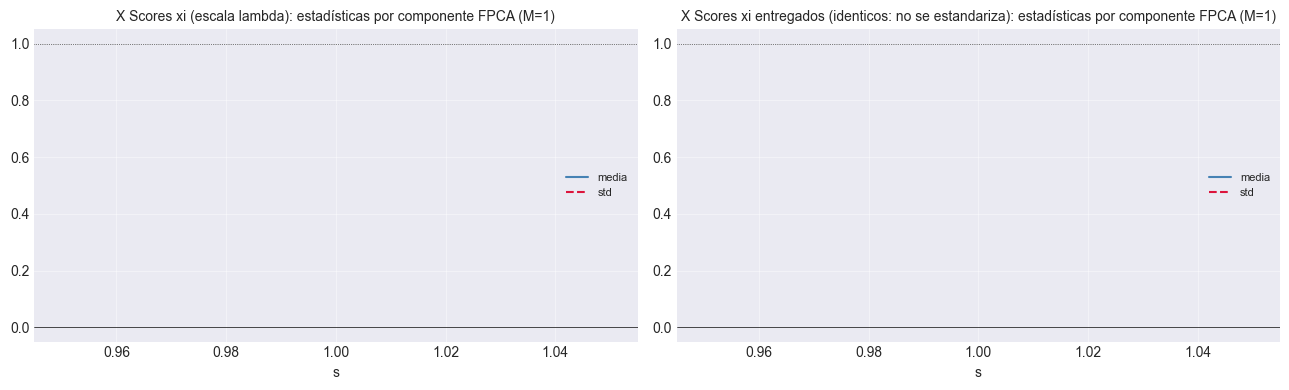

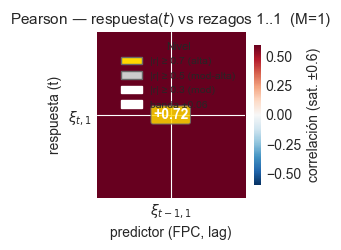

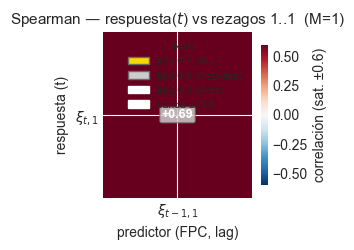

componentes : 1 -> índices [0]
N_LAGS      : 1   ·   p = 1 covariable(s) por componente (cruzadas)
n_train_eff : 1095   n_test_eff : 365
cov_por_comp: {0: ['fpc_1_lag1']}
[functional] 2 datasets + datasets_manifest.json
  fpc_1: train (1095, 2) · test (365, 2)

N_CHAINS = 3 cadenas por componente -> 3 jobs en MATLAB si se entrena este M
   k  fpc      var(y)     E[tau]        btau  taupsij
   0    1  3.2716e-01  3.057e+00  1.6358e-01  [3.274]
[out_artefact] hyperparameters.json -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\reales\real_sa1_precio_v02_m01
[out_artefact] eval_config.json


,n_test,RMSE_fpc1,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,
media_incondicional,365.0000,0.4895,0.4895,-0.0585,0.3854,0.6208
persistencia_lag1,365.0000,0.4070,0.4070,0.2683,0.3115,0.5581


contrato_ok = True   (M=1, K=29, T0=1096, n_components=1)
estandarizador ajustado con 1096 filas (T0=1096)
verificación FPCA: todo_ok = True

M = 2   ·   real_sa1_precio_v02_m02
M(95 %) según la regla : 10   (K disponible = 29)
M de este punto        : 2   <- DIFIERE de la regla: es un punto de sensibilidad
M = 2   var. explicada = 74.1819%
[train] max|media xi| = 1.88e-16   (~ 0)
[test]  max|media xi| = 0.115
[test]  var xi / lambda = [0.693 0.887]
[holdout] ajustado con 1096 filas = T0 (train[1:1096]) -> ok=True

SCORES_STD (1461, 2)   (= SCORES: transformacion identidad)
  [train] media = [-1.879e-16 -8.458e-17]   <- NO se resta
  [train] std   = [0.572 0.223]   <- NO se divide
  [test]  media = [-0.115  0.003]
  [test]  std   = [0.476 0.21 ]
  rango que vera MATLAB: [-1.487, 2.067]

[functional] artefactos FPCA · cond_W = 1.029e+01


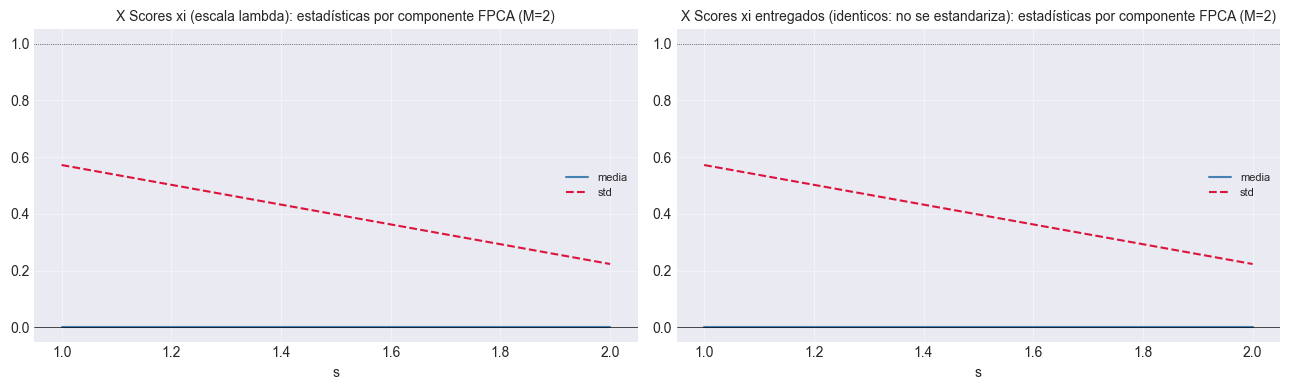

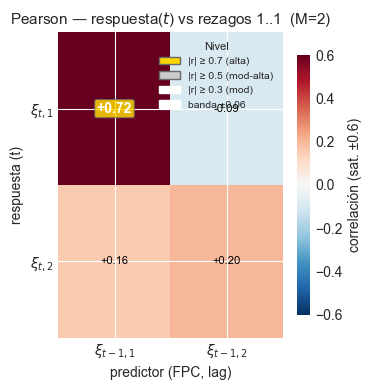

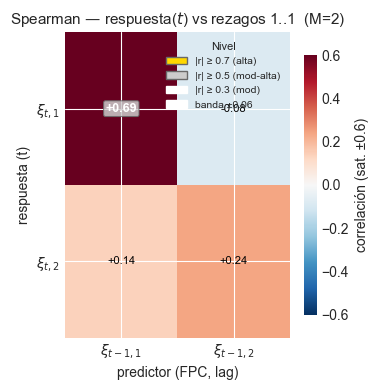

componentes : 2 -> índices [0, 1]
N_LAGS      : 1   ·   p = 2 covariable(s) por componente (cruzadas)
n_train_eff : 1095   n_test_eff : 365
cov_por_comp: {0: ['fpc_1_lag1', 'fpc_2_lag1'], 1: ['fpc_1_lag1', 'fpc_2_lag1']}
[functional] 4 datasets + datasets_manifest.json
  fpc_1: train (1095, 3) · test (365, 3)
  fpc_2: train (1095, 3) · test (365, 3)

N_CHAINS = 3 cadenas por componente -> 6 jobs en MATLAB si se entrena este M
   k  fpc      var(y)     E[tau]        btau  taupsij
   0    1  3.2716e-01  3.057e+00  1.6358e-01  [3.274 0.498]
   1    2  4.9871e-02  2.005e+01  2.4935e-02  [3.274 0.498]
[out_artefact] hyperparameters.json -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\reales\real_sa1_precio_v02_m02
[out_artefact] eval_config.json


,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,
media_incondicional,365.0000,0.4895,0.2101,0.3498,-0.0293,0.3854,0.6208
persistencia_lag1,365.0000,0.4070,0.2598,0.3334,-0.1306,0.3348,0.5786


contrato_ok = True   (M=2, K=29, T0=1096, n_components=2)
estandarizador ajustado con 1096 filas (T0=1096)
verificación FPCA: todo_ok = True

M = 3   ·   real_sa1_precio_v02_m03
M(95 %) según la regla : 10   (K disponible = 29)
M de este punto        : 3   <- DIFIERE de la regla: es un punto de sensibilidad
M = 3   var. explicada = 81.7499%
[train] max|media xi| = 1.88e-16   (~ 0)
[test]  max|media xi| = 0.115
[test]  var xi / lambda = [0.693 0.887 0.86 ]
[holdout] ajustado con 1096 filas = T0 (train[1:1096]) -> ok=True

SCORES_STD (1461, 3)   (= SCORES: transformacion identidad)
  [train] media = [-1.879e-16 -8.458e-17 -1.684e-16]   <- NO se resta
  [train] std   = [0.572 0.223 0.196]   <- NO se divide
  [test]  media = [-0.115  0.003  0.031]
  [test]  std   = [0.476 0.21  0.182]
  rango que vera MATLAB: [-1.487, 2.067]

[functional] artefactos FPCA · cond_W = 1.029e+01


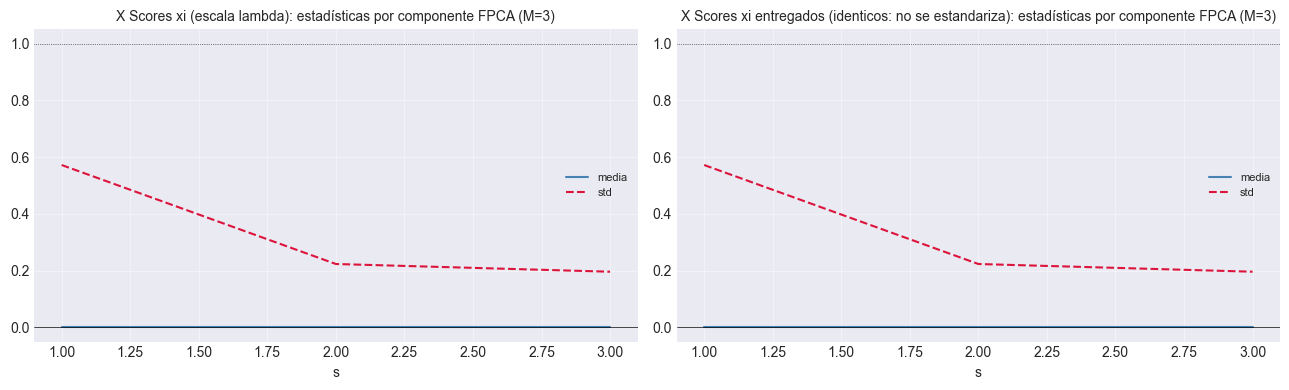

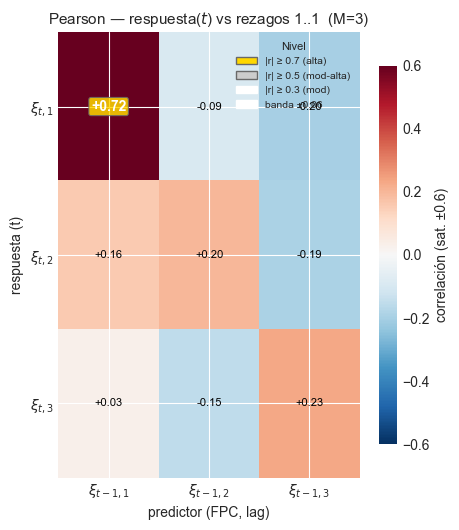

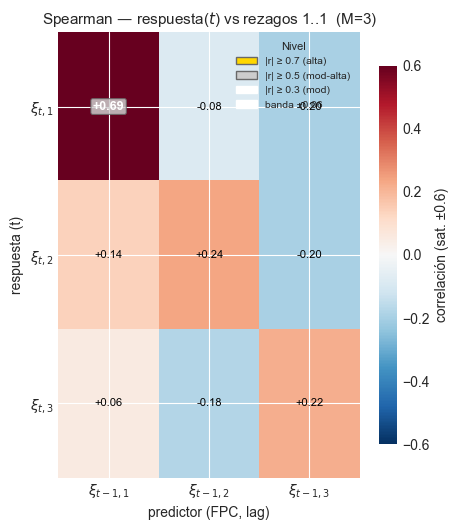

componentes : 3 -> índices [0, 1, 2]
N_LAGS      : 1   ·   p = 3 covariable(s) por componente (cruzadas)
n_train_eff : 1095   n_test_eff : 365
cov_por_comp: {0: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1'], 1: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1'], 2: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1']}
[functional] 6 datasets + datasets_manifest.json
  fpc_1: train (1095, 4) · test (365, 4)
  fpc_2: train (1095, 4) · test (365, 4)
  fpc_3: train (1095, 4) · test (365, 4)

N_CHAINS = 3 cadenas por componente -> 9 jobs en MATLAB si se entrena este M
   k  fpc      var(y)     E[tau]        btau  taupsij
   0    1  3.2716e-01  3.057e+00  1.6358e-01  [3.274 0.498 0.385]
   1    2  4.9871e-02  2.005e+01  2.4935e-02  [3.274 0.498 0.385]
   2    3  3.8464e-02  2.600e+01  1.9232e-02  [3.274 0.498 0.385]
[out_artefact] hyperparameters.json -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\reales\real_sa1_precio_v02_m03
[out_artefact] eval_config.json


,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,365.0000,0.4895,0.2101,0.1844,0.2947,-0.0295,0.3854,0.6208
persistencia_lag1,365.0000,0.4070,0.2598,0.2416,0.3028,-0.3432,0.3592,0.5993


contrato_ok = True   (M=3, K=29, T0=1096, n_components=3)
estandarizador ajustado con 1096 filas (T0=1096)
verificación FPCA: todo_ok = True

M = 4   ·   real_sa1_precio_v02_m04
M(95 %) según la regla : 10   (K disponible = 29)
M de este punto        : 4   <- DIFIERE de la regla: es un punto de sensibilidad
M = 4   var. explicada = 86.7709%
[train] max|media xi| = 1.88e-16   (~ 0)
[test]  max|media xi| = 0.115
[test]  var xi / lambda = [0.693 0.887 0.86  0.616]
[holdout] ajustado con 1096 filas = T0 (train[1:1096]) -> ok=True

SCORES_STD (1461, 4)   (= SCORES: transformacion identidad)
  [train] media = [-1.879e-16 -8.458e-17 -1.684e-16  1.647e-16]   <- NO se resta
  [train] std   = [0.572 0.223 0.196 0.16 ]   <- NO se divide
  [test]  media = [-0.115  0.003  0.031  0.022]
  [test]  std   = [0.476 0.21  0.182 0.125]
  rango que vera MATLAB: [-1.487, 2.067]

[functional] artefactos FPCA · cond_W = 1.029e+01


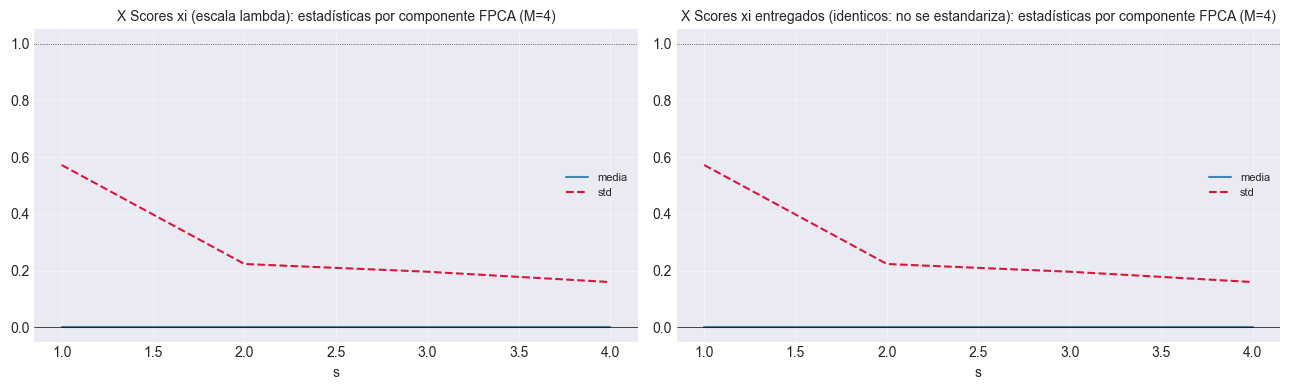

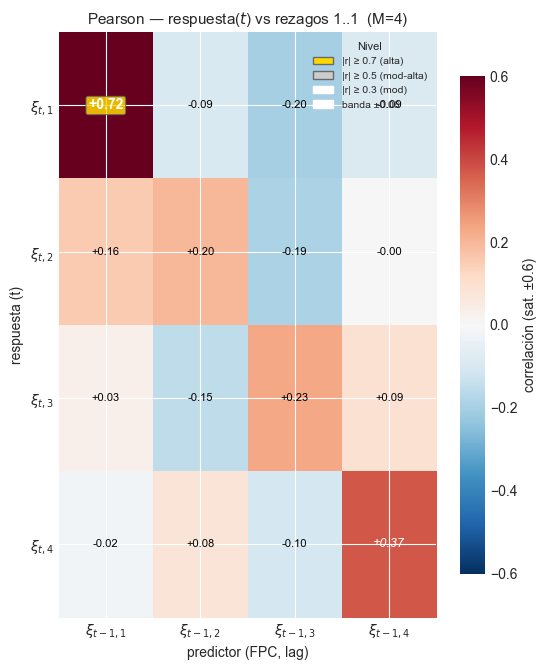

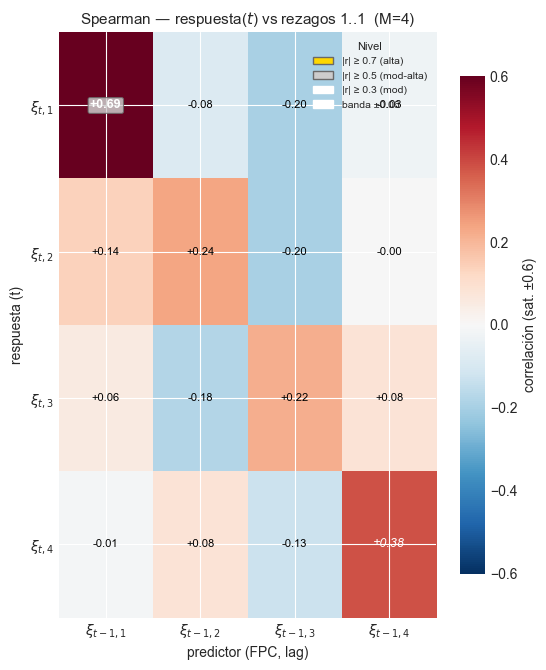

componentes : 4 -> índices [0, 1, 2, 3]
N_LAGS      : 1   ·   p = 4 covariable(s) por componente (cruzadas)
n_train_eff : 1095   n_test_eff : 365
cov_por_comp: {0: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1'], 1: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1'], 2: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1'], 3: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1']}
[functional] 8 datasets + datasets_manifest.json
  fpc_1: train (1095, 5) · test (365, 5)
  fpc_2: train (1095, 5) · test (365, 5)
  fpc_3: train (1095, 5) · test (365, 5)
  fpc_4: train (1095, 5) · test (365, 5)

N_CHAINS = 3 cadenas por componente -> 12 jobs en MATLAB si se entrena este M
   k  fpc      var(y)     E[tau]        btau  taupsij
   0    1  3.2716e-01  3.057e+00  1.6358e-01  [3.274 0.498 0.385 0.255]
   1    2  4.9871e-02  2.005e+01  2.4935e-02  [3.274 0.498 0.385 0.255]
   2    3  3.8464e-02  2.600e+01  1.9232e-02  [3.274 0.498 0.385 0.255]
   3    4  2.5519e-02  3.919e+01 

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,
media_incondicional,365.0000,0.4895,0.2101,0.1844,0.1272,0.2528,-0.0298,0.3854,0.6208
persistencia_lag1,365.0000,0.4070,0.2598,0.2416,0.1430,0.2629,-0.3332,0.3635,0.6029


contrato_ok = True   (M=4, K=29, T0=1096, n_components=4)
estandarizador ajustado con 1096 filas (T0=1096)
verificación FPCA: todo_ok = True

M = 5   ·   real_sa1_precio_v02_m05
M(95 %) según la regla : 10   (K disponible = 29)
M de este punto        : 5   <- DIFIERE de la regla: es un punto de sensibilidad
M = 5   var. explicada = 89.8083%
[train] max|media xi| = 1.88e-16   (~ 0)
[test]  max|media xi| = 0.115
[test]  var xi / lambda = [0.693 0.887 0.86  0.616 0.845]
[holdout] ajustado con 1096 filas = T0 (train[1:1096]) -> ok=True

SCORES_STD (1461, 5)   (= SCORES: transformacion identidad)
  [train] media = [-1.879e-16 -8.458e-17 -1.684e-16  1.647e-16 -1.275e-16]   <- NO se resta
  [train] std   = [0.572 0.223 0.196 0.16  0.124]   <- NO se divide
  [test]  media = [-0.115  0.003  0.031  0.022  0.024]
  [test]  std   = [0.476 0.21  0.182 0.125 0.114]
  rango que vera MATLAB: [-1.487, 2.067]

[functional] artefactos FPCA · cond_W = 1.029e+01


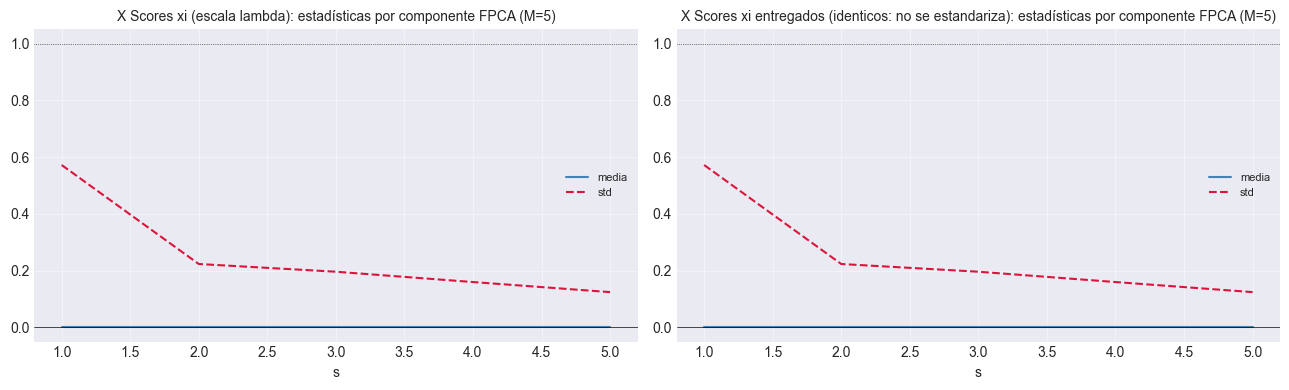

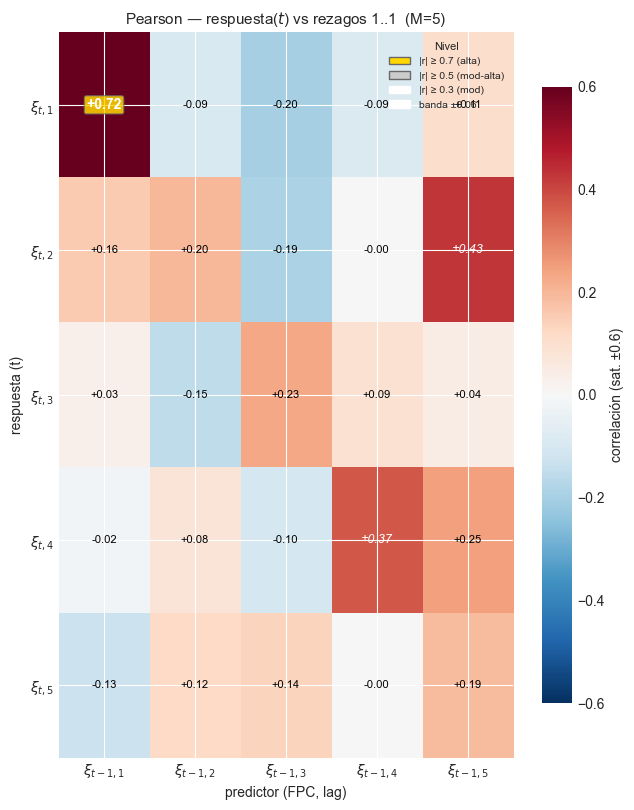

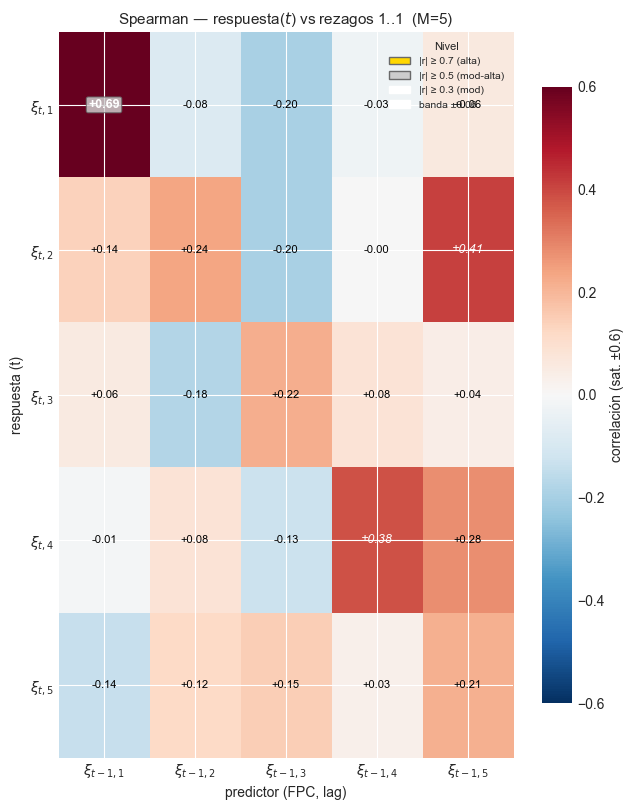

componentes : 5 -> índices [0, 1, 2, 3, 4]
N_LAGS      : 1   ·   p = 5 covariable(s) por componente (cruzadas)
n_train_eff : 1095   n_test_eff : 365
cov_por_comp: {0: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1'], 1: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1'], 2: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1'], 3: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1'], 4: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1']}
[functional] 10 datasets + datasets_manifest.json
  fpc_1: train (1095, 6) · test (365, 6)
  fpc_2: train (1095, 6) · test (365, 6)
  fpc_3: train (1095, 6) · test (365, 6)
  fpc_4: train (1095, 6) · test (365, 6)
  fpc_5: train (1095, 6) · test (365, 6)

N_CHAINS = 3 cadenas por componente -> 15 jobs en MATLAB si se entrena este M
   k  fpc      var(y)     E[tau]        btau  taupsij
   0    1  3.2716e-01  3.057e+00  1.6358e-01  [3.274 0.498 0.385 0.255 0.

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,
media_incondicional,365.0000,0.4895,0.2101,0.1844,0.1272,0.1166,0.2256,-0.0325,0.3854,0.6208
persistencia_lag1,365.0000,0.4070,0.2598,0.2416,0.1430,0.1555,0.2414,-0.4378,0.3741,0.6116


contrato_ok = True   (M=5, K=29, T0=1096, n_components=5)
estandarizador ajustado con 1096 filas (T0=1096)
verificación FPCA: todo_ok = True

M = 6   ·   real_sa1_precio_v02_m06
M(95 %) según la regla : 10   (K disponible = 29)
M de este punto        : 6   <- DIFIERE de la regla: es un punto de sensibilidad
M = 6   var. explicada = 91.4054%
[train] max|media xi| = 3.29e-16   (~ 0)
[test]  max|media xi| = 0.115
[test]  var xi / lambda = [0.693 0.887 0.86  0.616 0.845 0.745]
[holdout] ajustado con 1096 filas = T0 (train[1:1096]) -> ok=True

SCORES_STD (1461, 6)   (= SCORES: transformacion identidad)
  [train] media = [-1.879e-16 -8.458e-17 -1.684e-16  1.647e-16 -1.275e-16  3.287e-16]   <- NO se resta
  [train] std   = [0.572 0.223 0.196 0.16  0.124 0.09 ]   <- NO se divide
  [test]  media = [-0.115  0.003  0.031  0.022  0.024 -0.002]
  [test]  std   = [0.476 0.21  0.182 0.125 0.114 0.078]
  rango que vera MATLAB: [-1.487, 2.067]

[functional] artefactos FPCA · cond_W = 1.029e+01


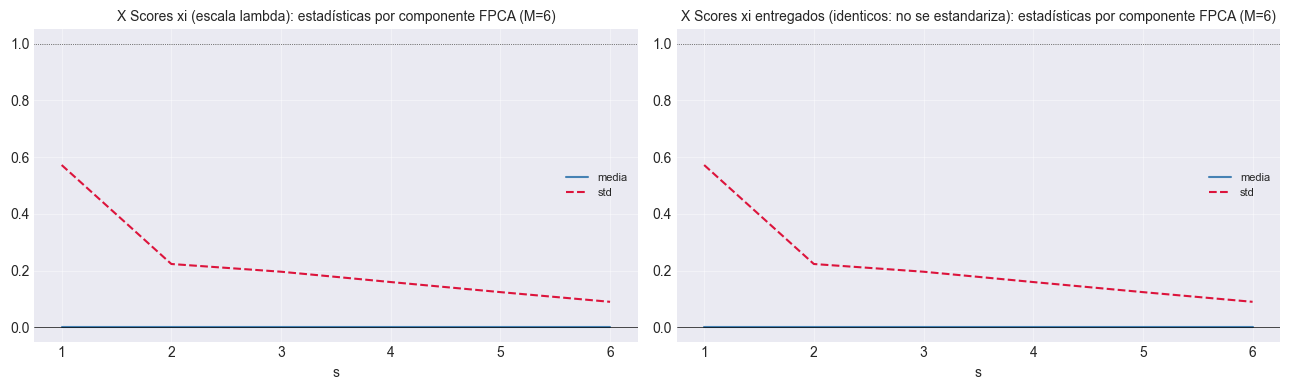

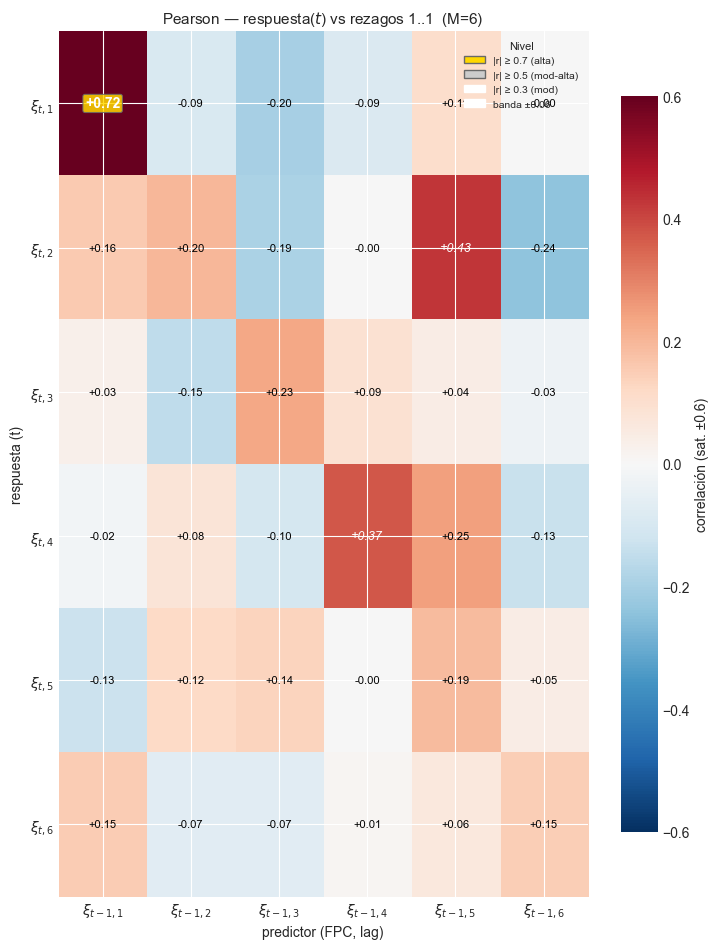

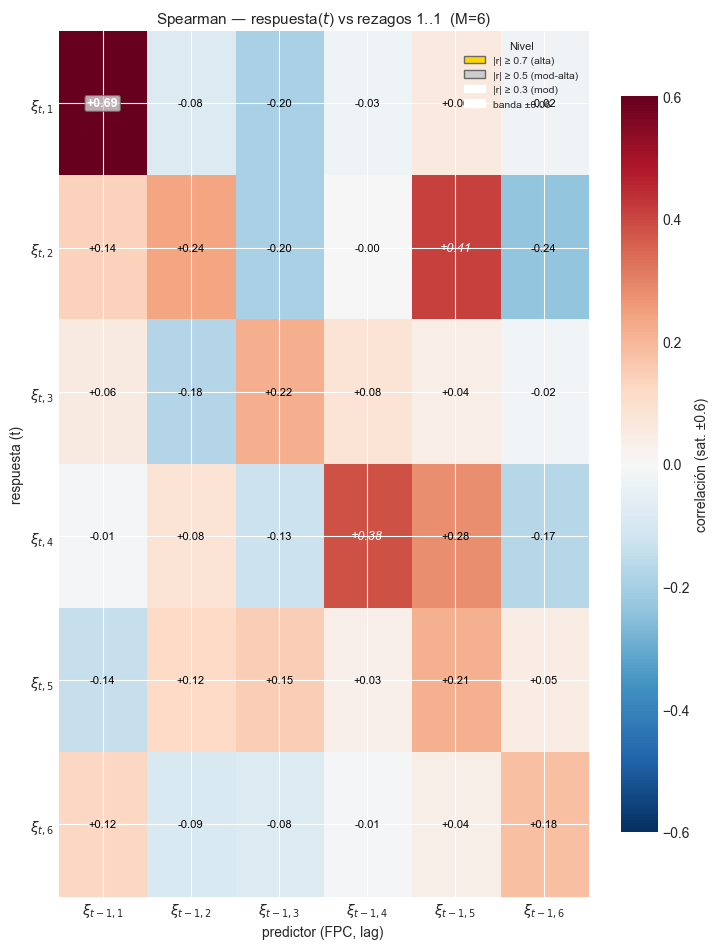

componentes : 6 -> índices [0, 1, 2, 3, 4, 5]
N_LAGS      : 1   ·   p = 6 covariable(s) por componente (cruzadas)
n_train_eff : 1095   n_test_eff : 365
cov_por_comp: {0: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1'], 1: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1'], 2: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1'], 3: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1'], 4: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1'], 5: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1']}
[functional] 12 datasets + datasets_manifest.json
  fpc_1: train (1095, 7) · test (365, 7)
  fpc_2: train (1095, 7) · test (365, 7)
  fpc_3: train (1095, 7) · test (365, 7)
  fpc_4: train (1095, 7) · test (365, 7)
  fpc_5: train (1095, 7) · test (365, 7)
  fpc_6: train (1095, 7) · test (365, 7)

N_

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_fpc6,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,,
media_incondicional,365.0000,0.4895,0.2101,0.1844,0.1272,0.1166,0.0777,0.2009,-0.0272,0.3854,0.6208
persistencia_lag1,365.0000,0.4070,0.2598,0.2416,0.1430,0.1555,0.0922,0.2165,-0.4327,0.3765,0.6136


contrato_ok = True   (M=6, K=29, T0=1096, n_components=6)
estandarizador ajustado con 1096 filas (T0=1096)
verificación FPCA: todo_ok = True

M = 7   ·   real_sa1_precio_v02_m07
M(95 %) según la regla : 10   (K disponible = 29)
M de este punto        : 7   <- DIFIERE de la regla: es un punto de sensibilidad
M = 7   var. explicada = 92.8710%
[train] max|media xi| = 3.29e-16   (~ 0)
[test]  max|media xi| = 0.115
[test]  var xi / lambda = [0.693 0.887 0.86  0.616 0.845 0.745 0.983]
[holdout] ajustado con 1096 filas = T0 (train[1:1096]) -> ok=True

SCORES_STD (1461, 7)   (= SCORES: transformacion identidad)
  [train] media = [-1.879e-16 -8.458e-17 -1.684e-16  1.647e-16 -1.275e-16  3.287e-16
  1.951e-16]   <- NO se resta
  [train] std   = [0.572 0.223 0.196 0.16  0.124 0.09  0.086]   <- NO se divide
  [test]  media = [-0.115  0.003  0.031  0.022  0.024 -0.002  0.008]
  [test]  std   = [0.476 0.21  0.182 0.125 0.114 0.078 0.085]
  rango que vera MATLAB: [-1.487, 2.067]

[functional] artefact

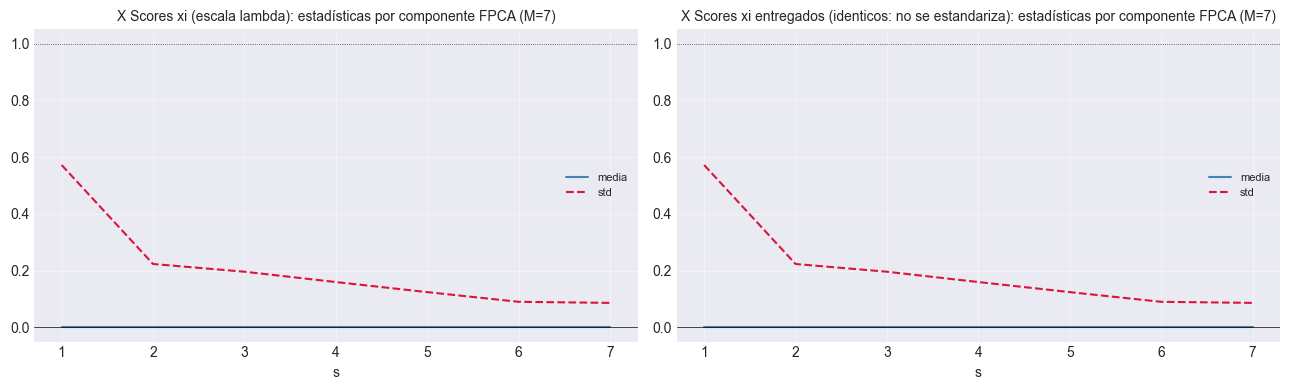

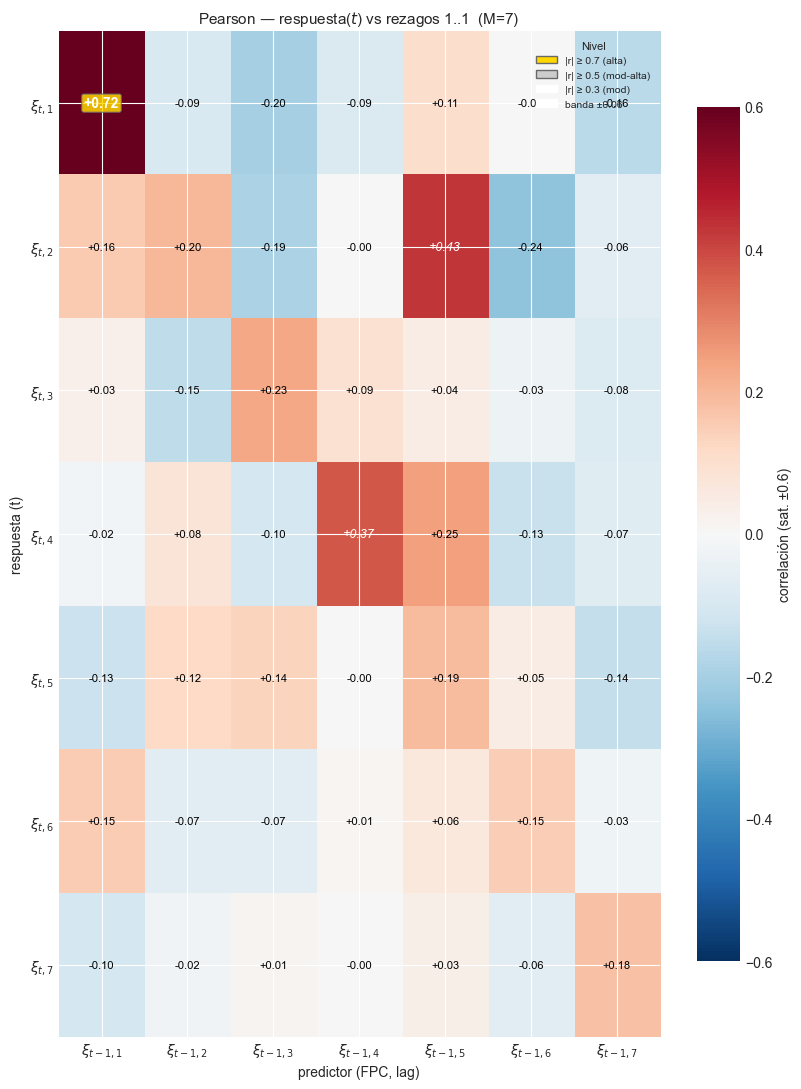

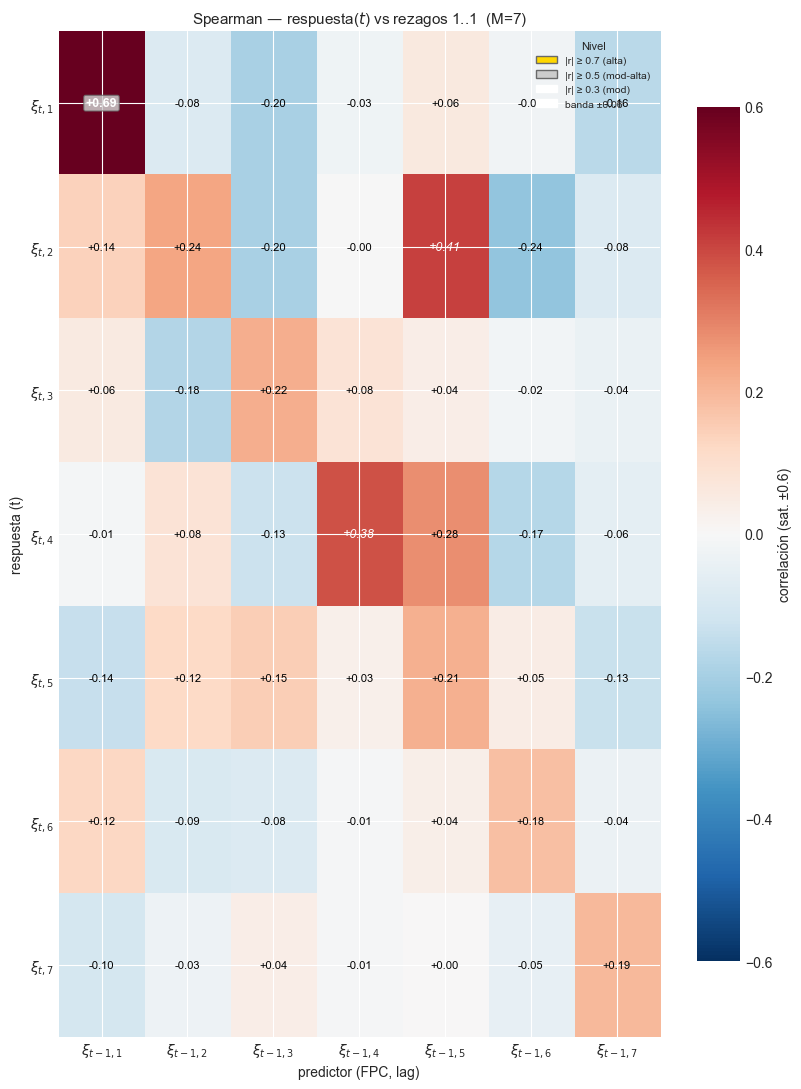

componentes : 7 -> índices [0, 1, 2, 3, 4, 5, 6]
N_LAGS      : 1   ·   p = 7 covariable(s) por componente (cruzadas)
n_train_eff : 1095   n_test_eff : 365
cov_por_comp: {0: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1'], 1: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1'], 2: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1'], 3: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1'], 4: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1'], 5: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1'], 6: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1']}
[functional] 14 datasets + datasets_manifest.json
  fpc_1: train (1095, 8) · test (365, 8)
  fpc_2: train (10

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_fpc6,RMSE_fpc7,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,,,
media_incondicional,365.0000,0.4895,0.2101,0.1844,0.1272,0.1166,0.0777,0.0859,0.1845,-0.0247,0.3854,0.6208
persistencia_lag1,365.0000,0.4070,0.2598,0.2416,0.1430,0.1555,0.0922,0.1132,0.2018,-0.4787,0.3820,0.6180


contrato_ok = True   (M=7, K=29, T0=1096, n_components=7)
estandarizador ajustado con 1096 filas (T0=1096)
verificación FPCA: todo_ok = True

M = 8   ·   real_sa1_precio_v02_m08
M(95 %) según la regla : 10   (K disponible = 29)
M de este punto        : 8   <- DIFIERE de la regla: es un punto de sensibilidad
M = 8   var. explicada = 93.8858%
[train] max|media xi| = 3.29e-16   (~ 0)
[test]  max|media xi| = 0.115
[test]  var xi / lambda = [0.693 0.887 0.86  0.616 0.845 0.745 0.983 0.603]
[holdout] ajustado con 1096 filas = T0 (train[1:1096]) -> ok=True

SCORES_STD (1461, 8)   (= SCORES: transformacion identidad)
  [train] media = [-1.879e-16 -8.458e-17 -1.684e-16  1.647e-16 -1.275e-16  3.287e-16
  1.951e-16  7.163e-17]   <- NO se resta
  [train] std   = [0.572 0.223 0.196 0.16  0.124 0.09  0.086 0.072]   <- NO se divide
  [test]  media = [-0.115  0.003  0.031  0.022  0.024 -0.002  0.008  0.004]
  [test]  std   = [0.476 0.21  0.182 0.125 0.114 0.078 0.085 0.056]
  rango que vera MATLAB: [-

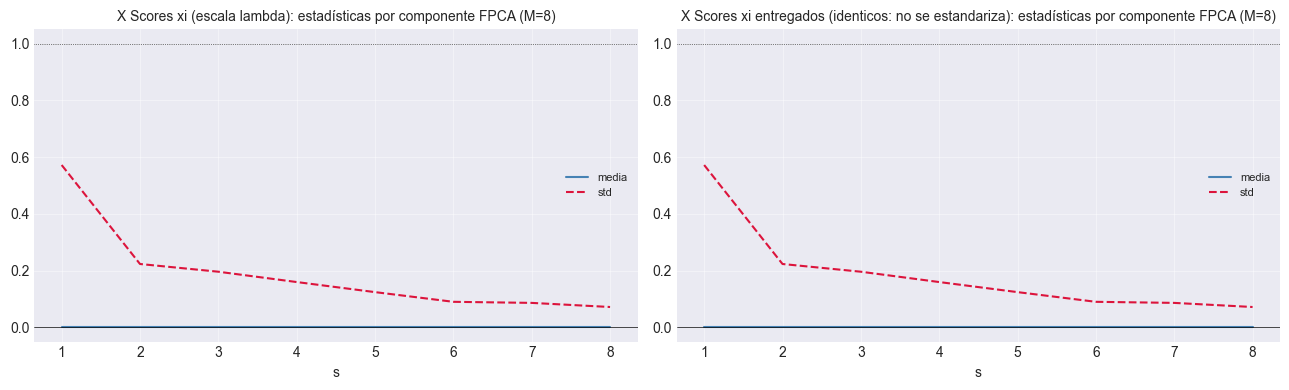

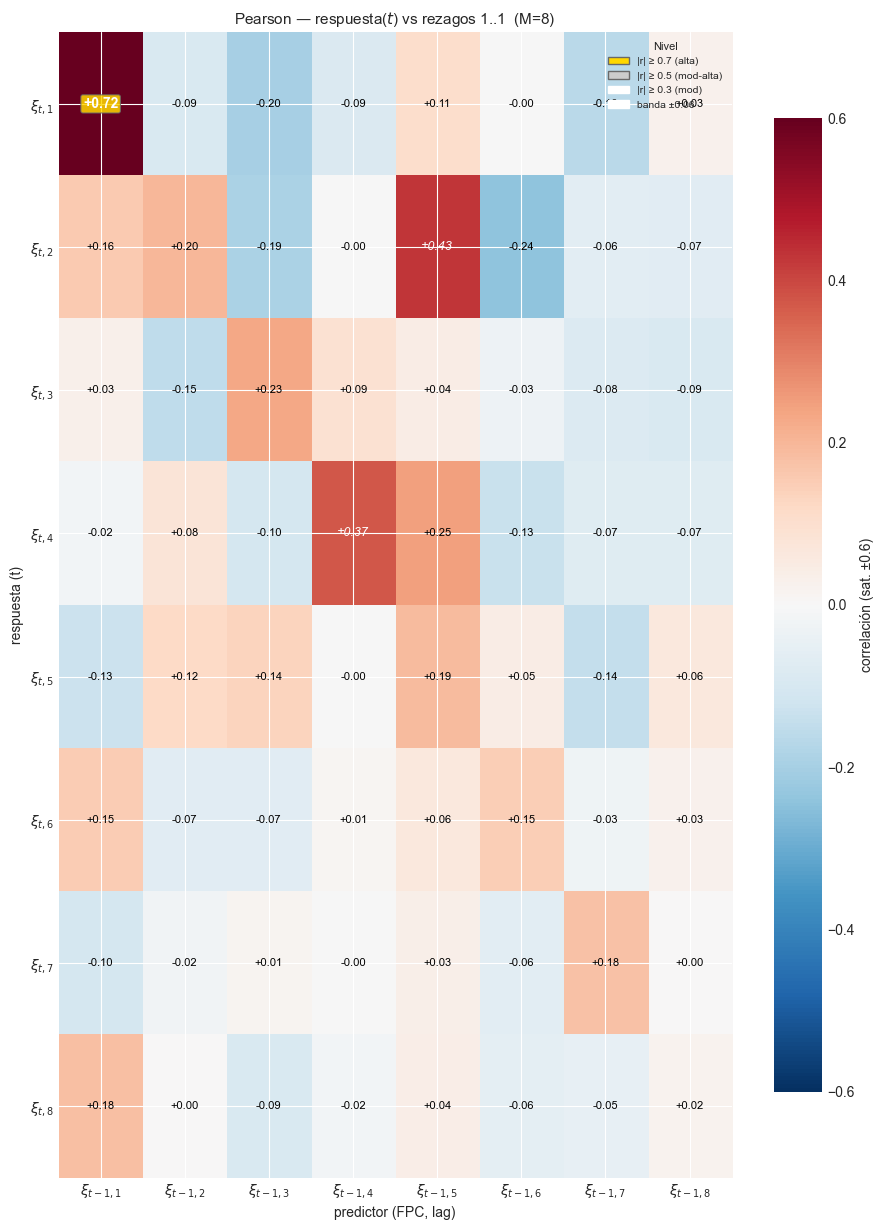

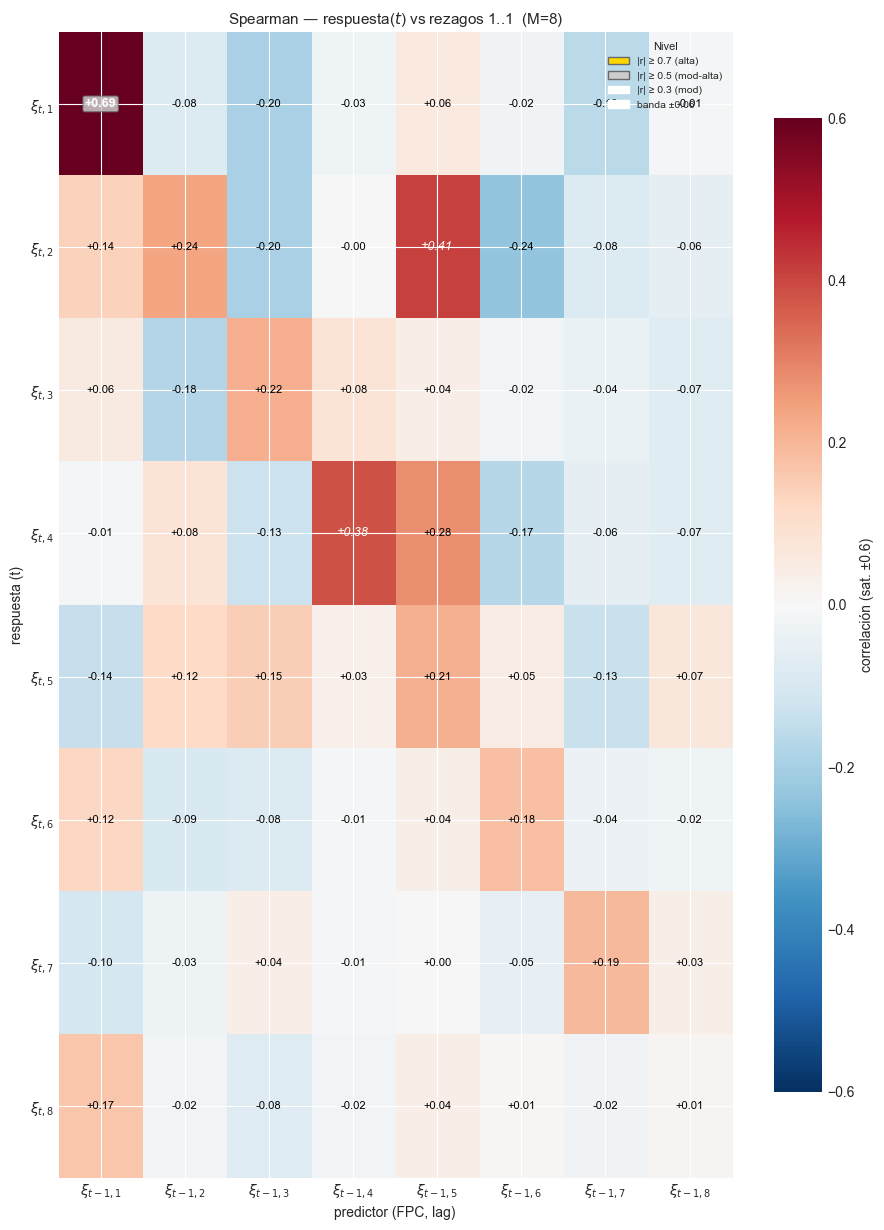

componentes : 8 -> índices [0, 1, 2, 3, 4, 5, 6, 7]
N_LAGS      : 1   ·   p = 8 covariable(s) por componente (cruzadas)
n_train_eff : 1095   n_test_eff : 365
cov_por_comp: {0: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1'], 1: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1'], 2: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1'], 3: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1'], 4: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1'], 5: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1'], 6: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1'], 7: ['fpc

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_fpc6,RMSE_fpc7,RMSE_fpc8,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,,,,
media_incondicional,365.0000,0.4895,0.2101,0.1844,0.1272,0.1166,0.0777,0.0859,0.0558,0.1684,-0.0221,0.3854,0.6208
persistencia_lag1,365.0000,0.4070,0.2598,0.2416,0.1430,0.1555,0.0922,0.1132,0.0785,0.1864,-0.5423,0.3850,0.6205


contrato_ok = True   (M=8, K=29, T0=1096, n_components=8)
estandarizador ajustado con 1096 filas (T0=1096)
verificación FPCA: todo_ok = True

M = 9   ·   real_sa1_precio_v02_m09
M(95 %) según la regla : 10   (K disponible = 29)
M de este punto        : 9   <- DIFIERE de la regla: es un punto de sensibilidad
M = 9   var. explicada = 94.7117%
[train] max|media xi| = 3.29e-16   (~ 0)
[test]  max|media xi| = 0.115
[test]  var xi / lambda = [0.693 0.887 0.86  0.616 0.845 0.745 0.983 0.603 0.763]
[holdout] ajustado con 1096 filas = T0 (train[1:1096]) -> ok=True

SCORES_STD (1461, 9)   (= SCORES: transformacion identidad)
  [train] media = [-1.879e-16 -8.458e-17 -1.684e-16  1.647e-16 -1.275e-16  3.287e-16
  1.951e-16  7.163e-17  4.926e-17]   <- NO se resta
  [train] std   = [0.572 0.223 0.196 0.16  0.124 0.09  0.086 0.072 0.065]   <- NO se divide
  [test]  media = [-0.115  0.003  0.031  0.022  0.024 -0.002  0.008  0.004 -0.005]
  [test]  std   = [0.476 0.21  0.182 0.125 0.114 0.078 0.085 0.05

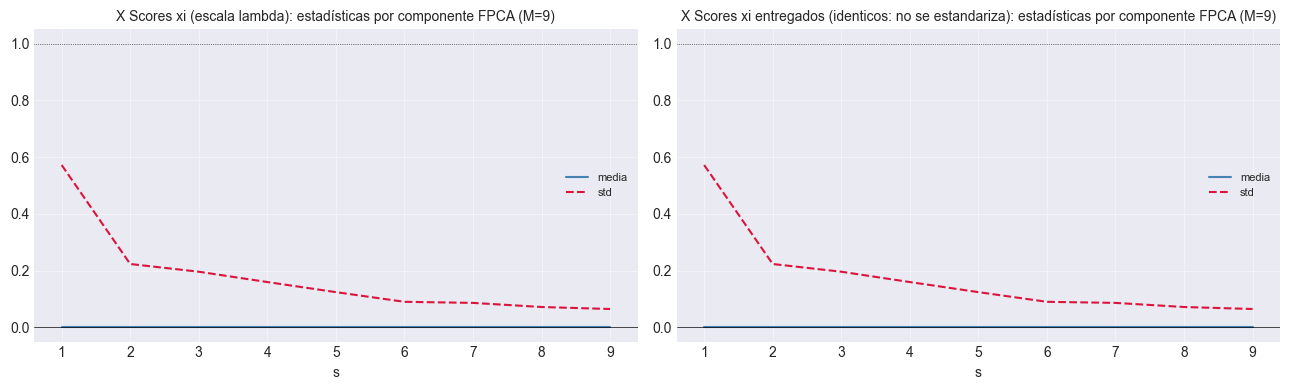

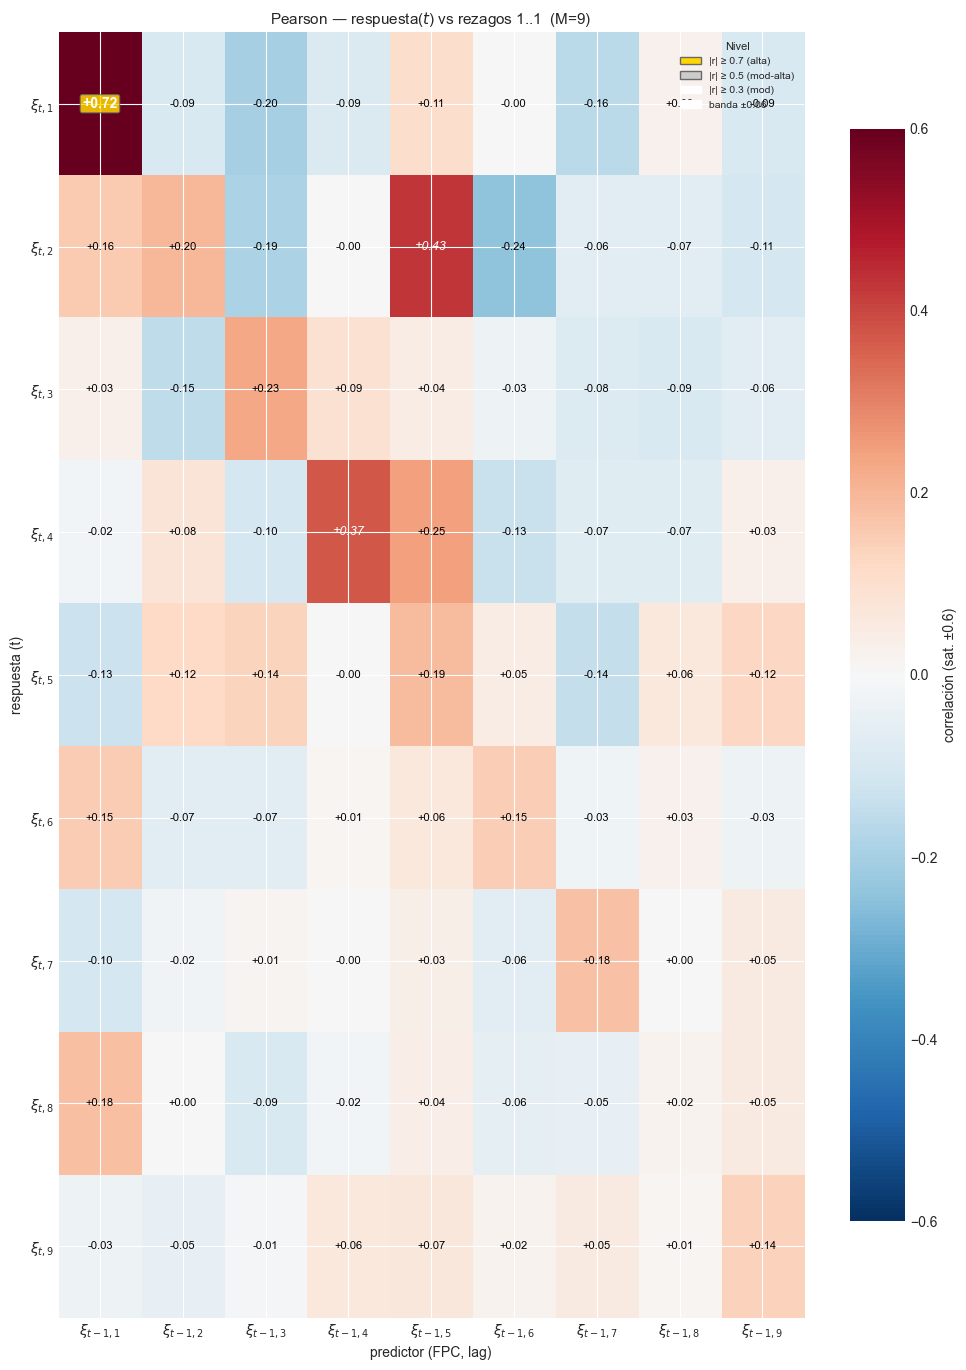

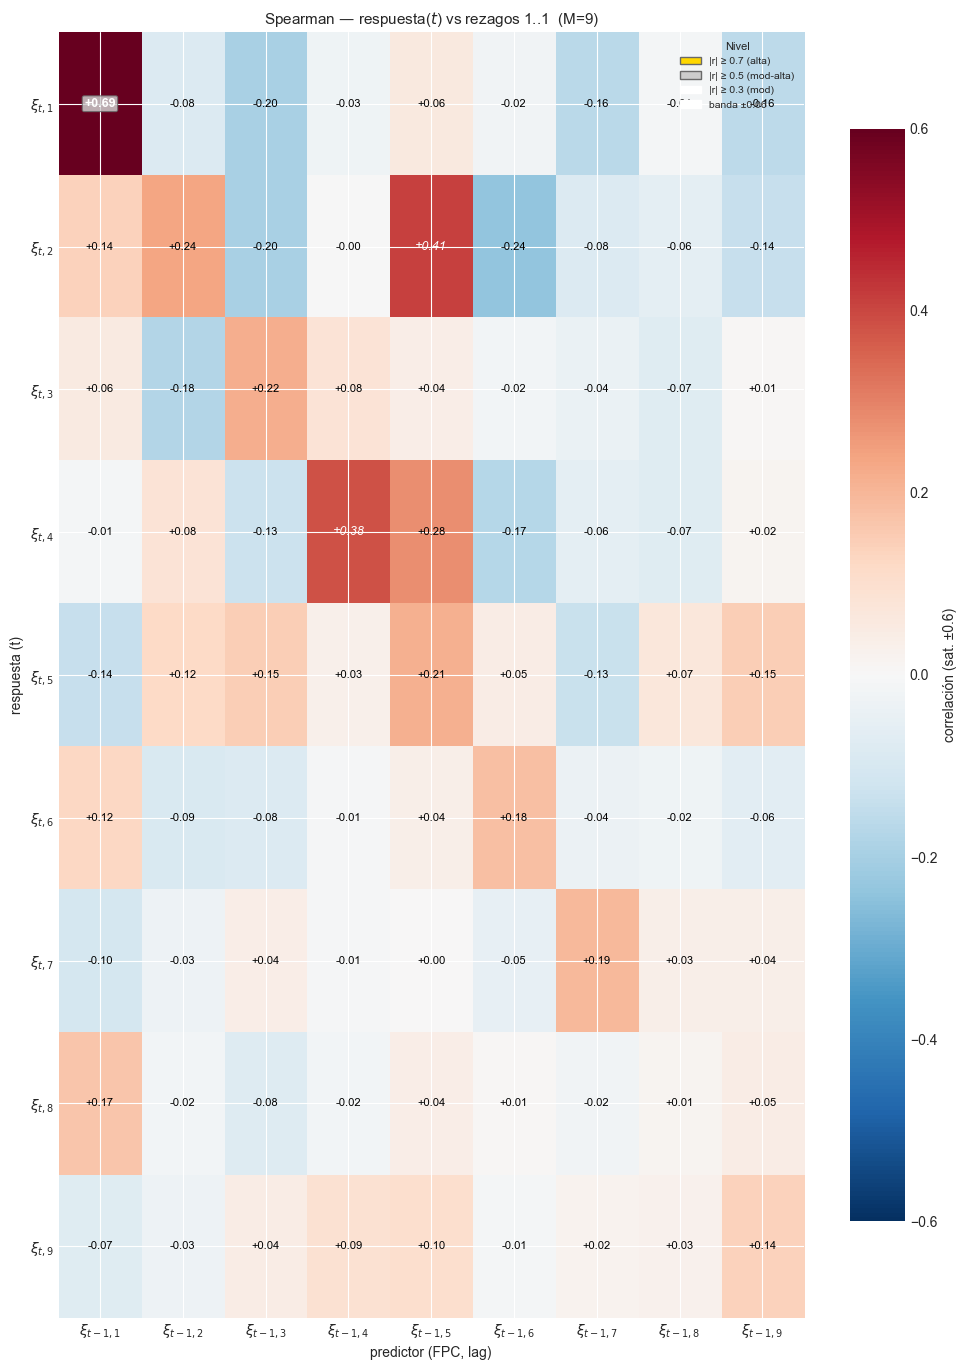

componentes : 9 -> índices [0, 1, 2, 3, 4, 5, 6, 7, 8]
N_LAGS      : 1   ·   p = 9 covariable(s) por componente (cruzadas)
n_train_eff : 1095   n_test_eff : 365
cov_por_comp: {0: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1', 'fpc_9_lag1'], 1: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1', 'fpc_9_lag1'], 2: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1', 'fpc_9_lag1'], 3: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1', 'fpc_9_lag1'], 4: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1', 'fpc_9_lag1'], 5: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1', 'fpc_9_lag1'], 6: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_fpc6,RMSE_fpc7,RMSE_fpc8,RMSE_fpc9,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,,,,,
media_incondicional,365.0000,0.4895,0.2101,0.1844,0.1272,0.1166,0.0777,0.0859,0.0558,0.0568,0.1560,-0.0206,0.3854,0.6208
persistencia_lag1,365.0000,0.4070,0.2598,0.2416,0.1430,0.1555,0.0922,0.1132,0.0785,0.0731,0.1738,-0.5566,0.3871,0.6222


contrato_ok = True   (M=9, K=29, T0=1096, n_components=9)
estandarizador ajustado con 1096 filas (T0=1096)
verificación FPCA: todo_ok = True

M = 10   ·   real_sa1_precio_v02_m10
M(95 %) según la regla : 10   (K disponible = 29)
M de este punto        : 10   (coincide con la regla)
M = 10   var. explicada = 95.4294%
[train] max|media xi| = 3.29e-16   (~ 0)
[test]  max|media xi| = 0.115
[test]  var xi / lambda = [0.693 0.887 0.86  0.616 0.845 0.745 0.983 0.603 0.763 0.669]
[holdout] ajustado con 1096 filas = T0 (train[1:1096]) -> ok=True

SCORES_STD (1461, 10)   (= SCORES: transformacion identidad)
  [train] media = [-1.879e-16 -8.458e-17 -1.684e-16  1.647e-16 -1.275e-16  3.287e-16
  1.951e-16  7.163e-17  4.926e-17  3.028e-16]   <- NO se resta
  [train] std   = [0.572 0.223 0.196 0.16  0.124 0.09  0.086 0.072 0.065 0.06 ]   <- NO se divide
  [test]  media = [-0.115  0.003  0.031  0.022  0.024 -0.002  0.008  0.004 -0.005  0.001]
  [test]  std   = [0.476 0.21  0.182 0.125 0.114 0.078 0.08

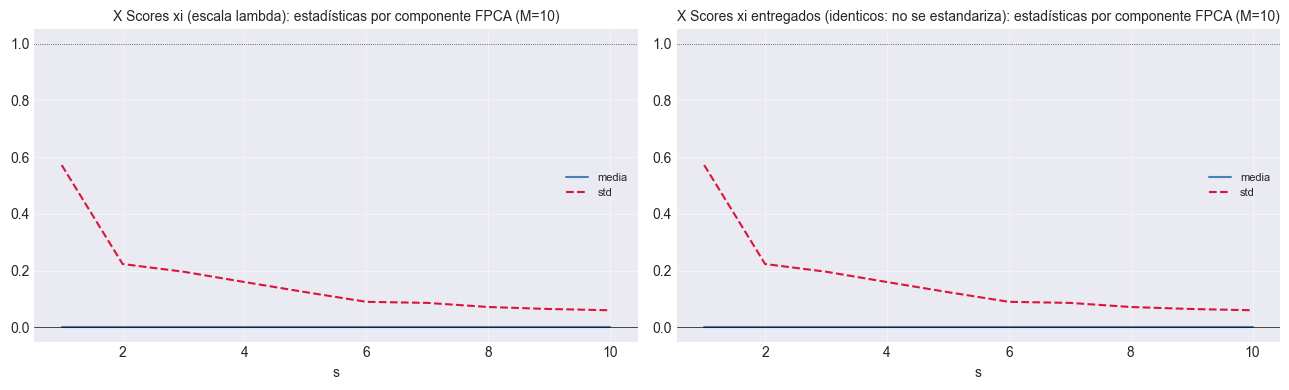

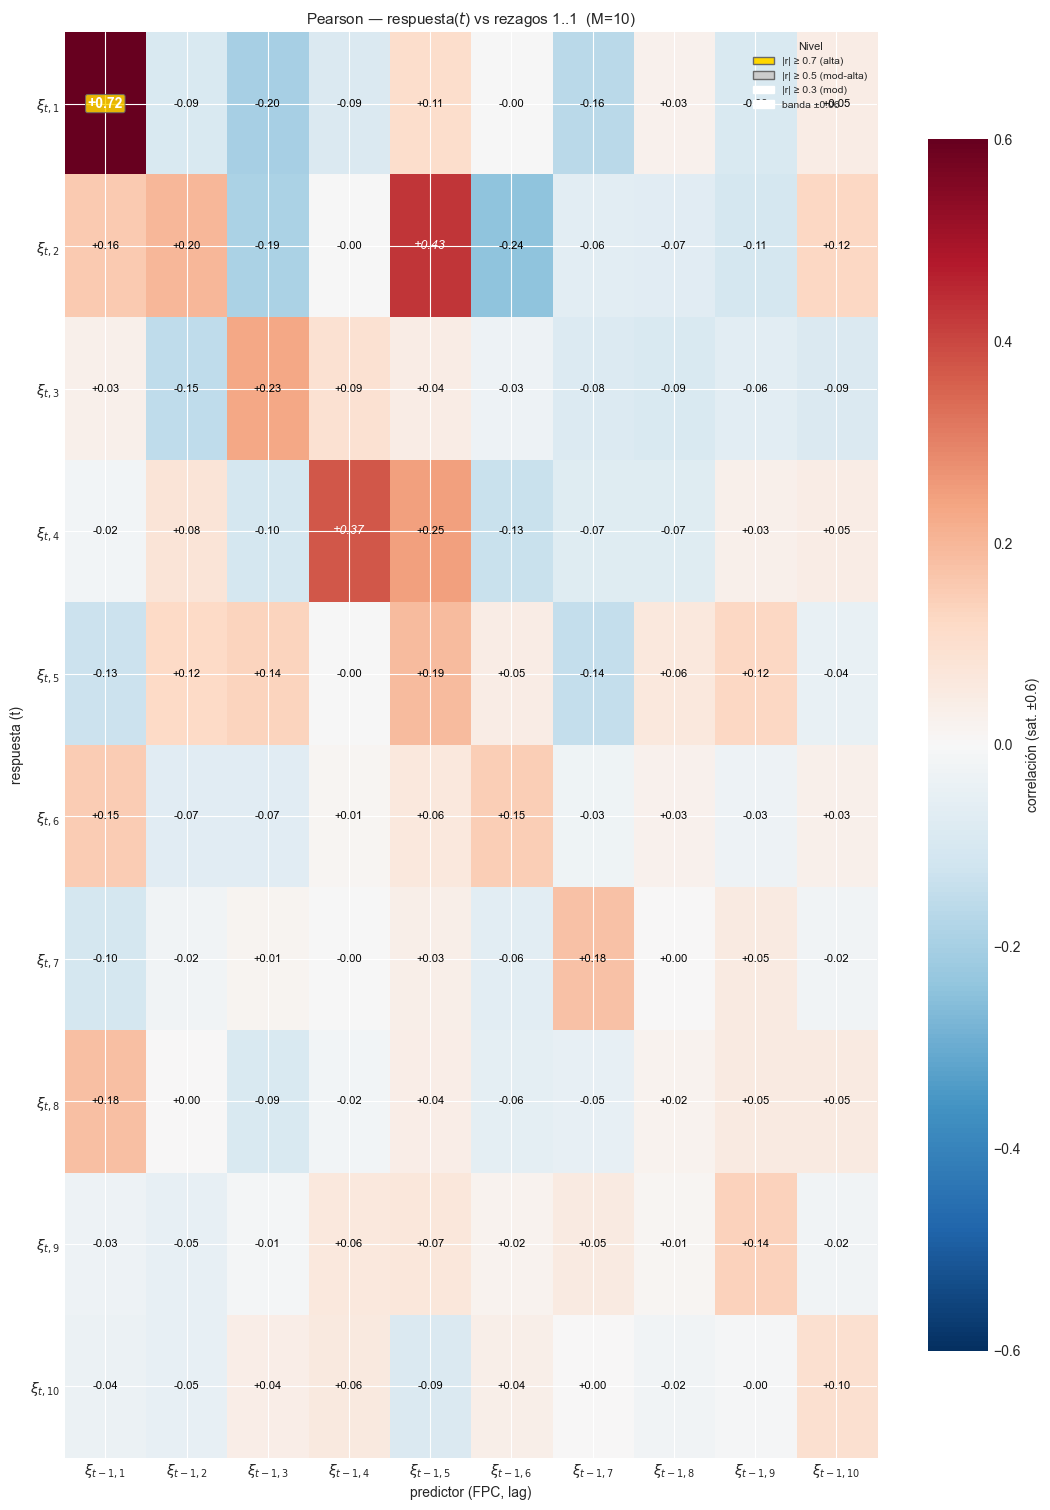

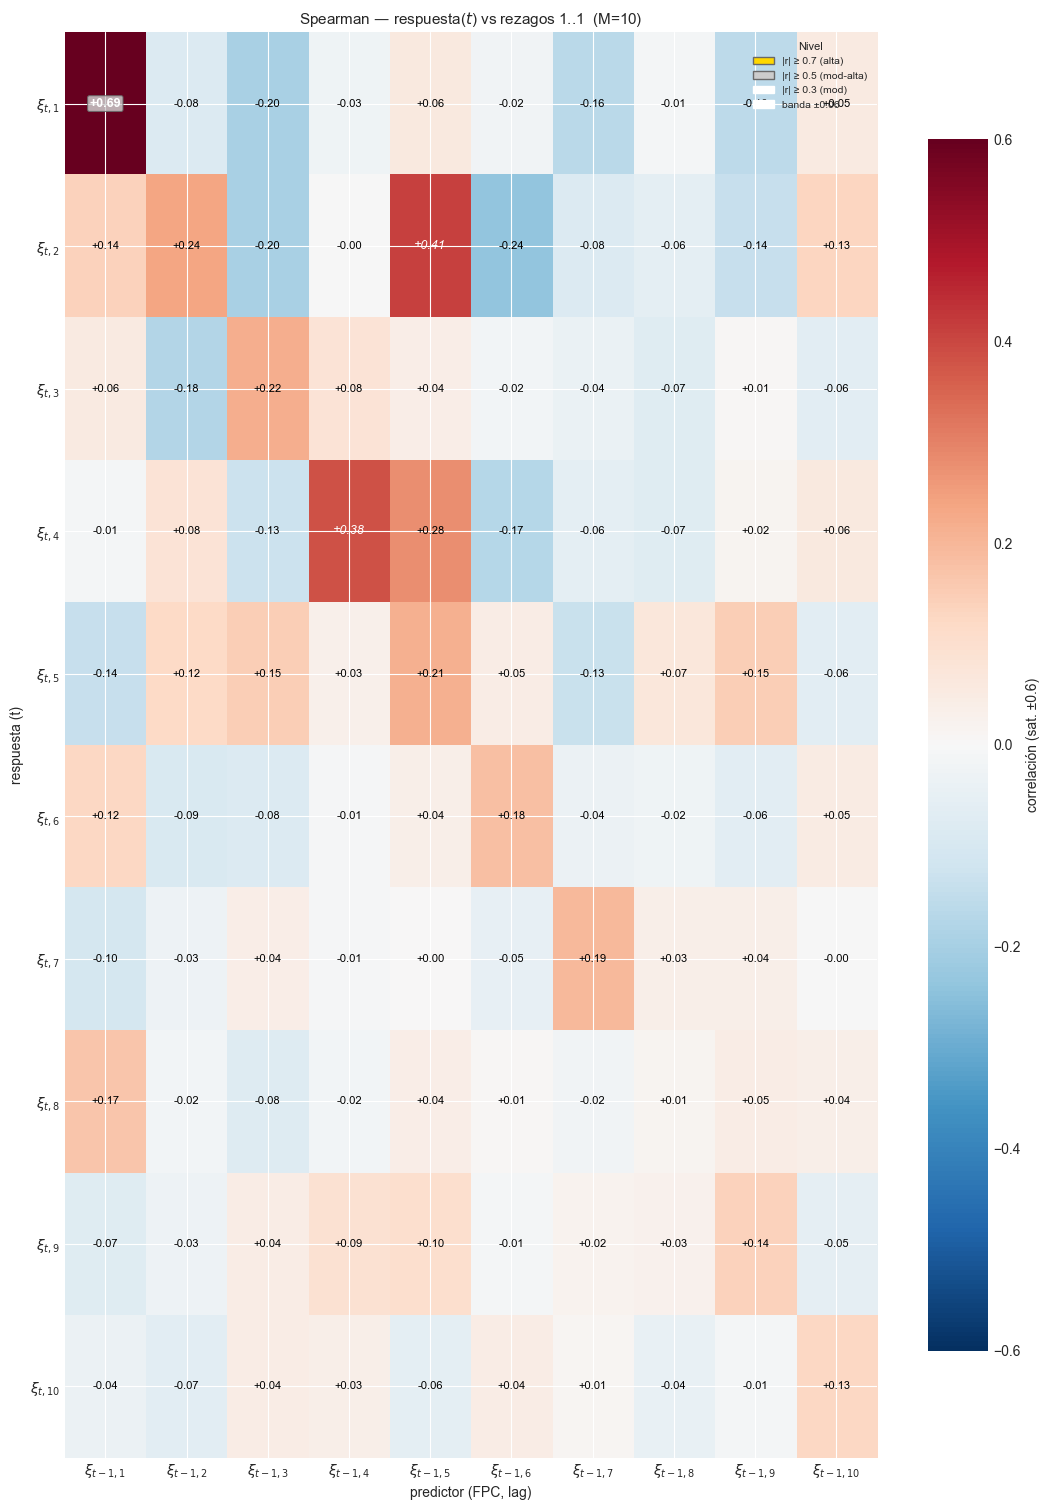

componentes : 10 -> índices [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
N_LAGS      : 1   ·   p = 10 covariable(s) por componente (cruzadas)
n_train_eff : 1095   n_test_eff : 365
cov_por_comp: {0: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1', 'fpc_9_lag1', 'fpc_10_lag1'], 1: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1', 'fpc_9_lag1', 'fpc_10_lag1'], 2: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1', 'fpc_9_lag1', 'fpc_10_lag1'], 3: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1', 'fpc_9_lag1', 'fpc_10_lag1'], 4: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1', 'fpc_9_lag1', 'fpc_10_lag1'], 5: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', '

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_fpc6,RMSE_fpc7,RMSE_fpc8,RMSE_fpc9,RMSE_fpc10,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,,,,,,
media_incondicional,365.0000,0.4895,0.2101,0.1844,0.1272,0.1166,0.0777,0.0859,0.0558,0.0568,0.0493,0.1453,-0.0185,0.3854,0.6208
persistencia_lag1,365.0000,0.4070,0.2598,0.2416,0.1430,0.1555,0.0922,0.1132,0.0785,0.0731,0.0666,0.1631,-0.5830,0.3891,0.6238


contrato_ok = True   (M=10, K=29, T0=1096, n_components=10)
estandarizador ajustado con 1096 filas (T0=1096)
verificación FPCA: todo_ok = True


In [20]:
VARIANTE = "chungEscG"      # solo se registra en hyperparameters.json

# -- [CONFIG] Comunes a TODOS los puntos del barrido -------------------------
# Cruzados: xi_(k,t) se predice con xi_(j,t-l), j = 1..M, l = 1..N_LAGS (p = M x N_LAGS).
N_LAGS_ADMITIDOS = (1,)   # esta corrida: un solo rezago
N_LAGS      = 1
assert N_LAGS in N_LAGS_ADMITIDOS, f"N_LAGS admitido: {N_LAGS_ADMITIDOS} (ver HP_BY_TYPE)."

MCMC_CONFIG = {"nsim": 2500, "burn": 500, "N": VAR_CFG["N"], "M": 50}   # ojo: ese M es G*
N_CHAINS    = 3

HP_GLOBAL = {"atau": 0.5, "btau": 0.5, "ag": 0.5, "bg": 0.5,
             "mumu": 0.0, "taumu": 1.0, "pwj": 0.5}

# Chung §4.2 llevado a la escala cruda. Si x = sd*z, el prior del paper sobre z
# equivale a taupsij = taupsij_z*sd_x^2 y btau = 0.5*sd_y^2 (se aplican en
# procesar_punto). Inclusion: (apij, bpij) = (1, 5), E[pi] = 0.167, igual para propias y cruzadas.
HP_CHUNG_ESC = {"taupsij_z": float(VAR_CFG["taupsij_z"]), "btau_z": 0.5,
                "ab_por_lag": {l: (1.0, 5.0) for l in range(1, N_LAGS + 1)},
                "ab_cruzado": (1.0, 5.0)}
HP_BY_TYPE = {f"own_lag{l}": {"apij": HP_CHUNG_ESC["ab_por_lag"][l][0],
                              "bpij": HP_CHUNG_ESC["ab_por_lag"][l][1]}
              for l in range(1, N_LAGS + 1)}
# Cruzados: el mismo (1, 5); lo unico que se ajusta a los datos es la escala (sd de train).
HP_BY_TYPE.update({f"cross_lag{l}": {"apij": HP_CHUNG_ESC["ab_cruzado"][0],
                                     "bpij": HP_CHUNG_ESC["ab_cruzado"][1]}
                   for l in range(1, N_LAGS + 1)})
print(f"VARIANTE {VARIANTE!r}: HP_GLOBAL={HP_GLOBAL}")
for _t, _v in HP_BY_TYPE.items():
    print(f"  {_t}: apij={_v['apij']}, bpij={_v['bpij']}  E[pi]={_v['apij'] / (_v['apij'] + _v['bpij']):.3f}")
print(f"N={MCMC_CONFIG['N']}  ·  mupsij=0, taupsij={HP_CHUNG_ESC['taupsij_z']:g}*sd_x^2, "
      "btau=0.5*sd_y^2 (Chung en escala cruda)")
print(f"N_LAGS={N_LAGS}  ·  MCMC_CONFIG={MCMC_CONFIG}  ·  N_CHAINS={N_CHAINS}")
print(f"Draws posteriores por score: "
      f"({MCMC_CONFIG['nsim']} - {MCMC_CONFIG['burn']}) x {N_CHAINS} = "
      f"{(MCMC_CONFIG['nsim'] - MCMC_CONFIG['burn']) * N_CHAINS}")

RESUMEN = [procesar_punto(M) for M in M_FPCA_LIST]


## 5. Resumen del barrido

In [21]:
resumen_df = pd.DataFrame(RESUMEN).set_index("M")
display(resumen_df[["experiment_id", "var_acum", "K", "coincide_regla_95",
                    "n_components", "p_covariables", "contrato_ok"]]
        .style.format({"var_acum": "{:.4%}"})
        .set_caption(f"Barrido en M · {EXPERIMENT_BASE} · "
                     f"K disponible = {resumen_df['K'].iloc[0]}"))

_fallidos = [r for r in RESUMEN if not r["contrato_ok"]]
for r in _fallidos:
    print(f"\n[FALLA] M={r['M']} ({r['experiment_id']}):")
    for p in r["problemas"]:
        print(f"  - {p}")
assert not _fallidos, (
    f"El contrato falla en M = {[r['M'] for r in _fallidos]}. No lanzar MATLAB: "
    f"psbp_fd_iteracion.m leería artefactos inconsistentes.")

print(f"\n{'='*70}\nListo. Siguiente paso, en MATLAB desde esta carpeta:\n"
      f"  >> psbp_fd_iteracion\n"
      f"con M_FPCA_LIST = {list(M_FPCA_LIST)}   (cruzados: se entrena CADA M)\n{'='*70}")

,experiment_id,var_acum,K,coincide_regla_95,n_components,p_covariables,contrato_ok
M,,,,,,,
1,real_sa1_precio_v02_m01,64.3697%,29,False,1,1,True
2,real_sa1_precio_v02_m02,74.1819%,29,False,2,2,True
3,real_sa1_precio_v02_m03,81.7499%,29,False,3,3,True
4,real_sa1_precio_v02_m04,86.7709%,29,False,4,4,True
5,real_sa1_precio_v02_m05,89.8083%,29,False,5,5,True
6,real_sa1_precio_v02_m06,91.4054%,29,False,6,6,True
7,real_sa1_precio_v02_m07,92.8710%,29,False,7,7,True
8,real_sa1_precio_v02_m08,93.8858%,29,False,8,8,True
9,real_sa1_precio_v02_m09,94.7117%,29,False,9,9,True



Listo. Siguiente paso, en MATLAB desde esta carpeta:
  >> psbp_fd_iteracion
con M_FPCA_LIST = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]   (cruzados: se entrena CADA M)
